In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels/20_20151129_night.mat
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels/3_20151024_noon.mat
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels/10_20151125_noon.mat
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels/6_20151121_noon.mat
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels/18_20150926_noon.mat
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels/4_20151107_noon.mat
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels/14_20151014_night.mat
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels/7_20151015_night.mat
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels/21_20151016_noon.mat
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels/1_20151124_noon_2.mat
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels/15_20151126_night.mat
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels/13_20150929_noon.mat
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_

# **STAGE 0**

In [1]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [2]:
for root, dirs, files in os.walk('/kaggle/input/datasets'):
    print(root)

/kaggle/input/datasets
/kaggle/input/datasets/jaykd33
/kaggle/input/datasets/jaykd33/eeg-dataset
/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels
/kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands


In [3]:
# ============================================================
# STAGE 0: SEED-VIG DATASET AUDIT
# Notebook: stage0_dataset_audit.ipynb
# ============================================================
# PURPOSE: Understand dataset structure, label distributions,
# and ground truth trajectory smoothness before any modeling.
# This is not preprocessing. This is scientific due diligence.
# ============================================================

import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import pandas as pd
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# BLOCK 0.1: LOCATE AND INVENTORY THE DATASET
# ============================================================
# SEED-VIG contains EEG (.mat files) and eye movement data.
# Structure: Each subject has multiple sessions.
# EEG features are pre-extracted as Differential Entropy (DE).
# We use DE features, not raw EEG, consistent with prior work.
# ============================================================

# Adjust this path to match your Kaggle dataset mount point
DATASET_ROOT = '/kaggle/input/datasets'  # adjust if needed

def find_mat_files(root):
    """Recursively find all .mat files and report structure."""
    mat_files = []
    for path in Path(root).rglob('*.mat'):
        mat_files.append(str(path))
    return sorted(mat_files)

mat_files = find_mat_files(DATASET_ROOT)
print(f"Total .mat files found: {len(mat_files)}")
print("\nFirst 10 files:")
for f in mat_files[:10]:
    print(f"  {f}")

# ============================================================
# EXPECTED: You should see files organized by subject.
# SEED-VIG has 23 subjects. Each .mat file typically contains
# DE features (shape: n_samples x n_channels x n_freq_bands)
# and PERCLOS labels.
# IF YOU SEE 0 FILES: Your dataset path is wrong. Check:
#   import os; os.listdir('/kaggle/input/')
# ============================================================

Total .mat files found: 46

First 10 files:
  /kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands/10_20151125_noon.mat
  /kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands/11_20151024_night.mat
  /kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands/12_20150928_noon.mat
  /kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands/13_20150929_noon.mat
  /kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands/14_20151014_night.mat
  /kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands/15_20151126_night.mat
  /kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands/16_20151128_night.mat
  /kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands/17_20150925_noon.mat
  /kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands/18_20150926_noon.mat
  /kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands/19_20151114_noon.mat


In [4]:
# ============================================================
# BLOCK 0.2: LOAD AND INSPECT A SINGLE SESSION
# ============================================================
# Before writing any loop, understand the exact data structure
# of one file. .mat files can have different internal layouts
# depending on MATLAB version used to create them.
# ============================================================

def load_seed_vig_file(filepath):
    """
    Load a SEED-VIG .mat file and return its contents.
    Handles both old-style and new-style .mat files.
    """
    try:
        # Try standard scipy loader first (works for MATLAB < 7.3)
        data = sio.loadmat(filepath, squeeze_me=True, struct_as_record=False)
        return data, 'scipy'
    except Exception as e:
        print(f"scipy failed: {e}")
        try:
            # Fall back to h5py for MATLAB 7.3 HDF5 format
            import h5py
            data = h5py.File(filepath, 'r')
            return data, 'h5py'
        except Exception as e2:
            print(f"h5py also failed: {e2}")
            return None, None

# Load first file and inspect all keys
sample_file = mat_files[0]
data, loader_type = load_seed_vig_file(sample_file)

print(f"File: {sample_file}")
print(f"Loader used: {loader_type}")
print(f"\nTop-level keys: {list(data.keys())}")
print("\nDetailed inspection:")
for key in data.keys():
    if not key.startswith('__'):
        val = data[key]
        if hasattr(val, 'shape'):
            print(f"  {key}: shape={val.shape}, dtype={val.dtype}")
        else:
            print(f"  {key}: type={type(val)}, value={val}")

# ============================================================
# EXPECTED OUTPUT WILL VARY by dataset version.
# Common SEED-VIG layouts:
#   Option A: keys like 'EEG', 'perclos_label', 'de_feature'
#   Option B: keys like 'data', 'label'
#   Option C: separate EEG and label files per subject
#
# CRITICAL: Note the exact key names. You will need them below.
# PITFALL: Some versions store labels as 3-class (0,1,2) and
# some as continuous PERCLOS values. Confirm which you have.
# ============================================================

File: /kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands/10_20151125_noon.mat
Loader used: scipy

Top-level keys: ['__header__', '__version__', '__globals__', 'psd_movingAve', 'psd_LDS', 'de_movingAve', 'de_LDS']

Detailed inspection:
  psd_movingAve: shape=(17, 885, 5), dtype=float64
  psd_LDS: shape=(17, 885, 5), dtype=float64
  de_movingAve: shape=(17, 885, 5), dtype=float64
  de_LDS: shape=(17, 885, 5), dtype=float64


In [5]:
# ============================================================
# BLOCK 0.3: EXTRACT DE FEATURES AND LABELS — DEFINE SCHEMA
# ============================================================
# Based on Block 0.2 output, define the exact extraction
# function for your specific dataset layout.
#
# SEED-VIG DE features: typically 5 frequency bands
# (delta, theta, alpha, beta, gamma) x 17 or 32 channels
# Sampling: typically 1 feature vector per second or per epoch
# Labels: PERCLOS continuous OR discretized to 3 classes
# ============================================================

# -----------------------------------------------------------
# YOU MUST EDIT THIS FUNCTION based on Block 0.2 output
# Replace 'EEG_Feature' and 'perclos' with actual key names
# -----------------------------------------------------------

def extract_features_and_labels(filepath):
    """
    Extract DE features and PERCLOS labels from one session file.
    
    Returns:
        features: np.array of shape (T, C*F) where T=time steps,
                  C=channels, F=frequency bands
        labels:   np.array of shape (T,) — PERCLOS values or classes
        success:  bool
    """
    data, loader_type = load_seed_vig_file(filepath)
    if data is None:
        return None, None, False
    
    # --------------------------------------------------------
    # ADAPT THESE KEY NAMES to match your Block 0.2 output
    # Common possibilities shown below — uncomment the right one
    # --------------------------------------------------------
    
    # Option A: direct numpy arrays
    # features = data['EEG_Feature']  # shape: (T, channels, bands) or (T, channels*bands)
    # labels = data['perclos']
    
    # Option B: nested struct
    # features = data['data']['EEG'][:]
    # labels = data['data']['label'][:]
    
    # Option C: separate feature key
    # features = data['de_feature']  # shape depends on version
    # labels = data['label']
    
    # --------------------------------------------------------
    # GENERIC APPROACH: print all numeric arrays, pick correct ones
    # --------------------------------------------------------
    arrays = {k: v for k, v in data.items() 
              if not k.startswith('__') and hasattr(v, 'shape')}
    
    print(f"\nArrays in {Path(filepath).name}:")
    for k, v in arrays.items():
        print(f"  {k}: shape={v.shape}, min={v.min():.4f}, max={v.max():.4f}")
    
    return arrays, None, True

# Run on first 3 files to see if structure is consistent
for f in mat_files[:3]:
    extract_features_and_labels(f)

# ============================================================
# STOP HERE. Read the output carefully.
# You now need to identify:
# 1. Which key contains DE features
# 2. Which key contains labels
# 3. Whether labels are continuous PERCLOS (0-1) or categorical (0,1,2)
# 4. Whether shape is (T, C, F) or (T, C*F) or something else
# UPDATE extract_features_and_labels ACCORDINGLY before proceeding
# ============================================================


Arrays in 10_20151125_noon.mat:
  psd_movingAve: shape=(17, 885, 5), min=468.6547, max=25381747.6570
  psd_LDS: shape=(17, 885, 5), min=478.4687, max=25460418.4646
  de_movingAve: shape=(17, 885, 5), min=15.5003, max=27.8051
  de_LDS: shape=(17, 885, 5), min=15.5303, max=27.2969

Arrays in 11_20151024_night.mat:
  psd_movingAve: shape=(17, 885, 5), min=1172.7432, max=346022997.4181
  psd_LDS: shape=(17, 885, 5), min=1336.3057, max=350160892.1359
  de_movingAve: shape=(17, 885, 5), min=16.7795, max=28.3883
  de_LDS: shape=(17, 885, 5), min=16.9914, max=27.6907

Arrays in 12_20150928_noon.mat:
  psd_movingAve: shape=(17, 885, 5), min=135.4448, max=24474194.8264
  psd_LDS: shape=(17, 885, 5), min=140.4963, max=24444386.1575
  de_movingAve: shape=(17, 885, 5), min=13.7226, max=27.7695
  de_LDS: shape=(17, 885, 5), min=13.7682, max=27.7528


In [6]:
# ============================================================
# INSPECT ONE PERCLOS LABEL FILE
# ============================================================

from pathlib import Path
import scipy.io as sio

# Path to your PERCLOS label folder
LABEL_ROOT = "/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels"

# Find all .mat files
label_files = sorted(Path(LABEL_ROOT).glob("*.mat"))

print(f"Total label files found: {len(label_files)}")

# Load the first label file
sample_label_file = label_files[0]

print(f"\nInspecting: {sample_label_file.name}")

data = sio.loadmat(sample_label_file, squeeze_me=True, struct_as_record=False)

print("\nTop-level keys:")
print(list(data.keys()))

print("\nDetailed inspection:")
for key, value in data.items():
    if not key.startswith("__"):
        if hasattr(value, "shape"):
            print(f"{key}: shape={value.shape}, dtype={value.dtype}")

            # Show first few values
            try:
                print("First 10 values:")
                print(value.flatten()[:10])
            except:
                pass

            # Show min and max
            try:
                print(f"Min = {value.min():.4f}")
                print(f"Max = {value.max():.4f}")
            except:
                pass

            print("-" * 50)
        else:
            print(f"{key}: {type(value)}")

Total label files found: 23

Inspecting: 10_20151125_noon.mat

Top-level keys:
['__header__', '__version__', '__globals__', 'perclos']

Detailed inspection:
perclos: shape=(885,), dtype=float64
First 10 values:
[0.11845    0.11390556 0.11277667 0.1108381  0.10859074 0.10750758
 0.11302564 0.12480444 0.13923333 0.14997018]
Min = 0.1075
Max = 0.7999
--------------------------------------------------


In [7]:
EEG_ROOT="/kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands"
LABEL_ROOT = "/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels"
eeg_mat_files = sorted(Path(EEG_ROOT).glob("*.mat"))
label_mat_files = sorted(Path(LABEL_ROOT).glob("*.mat"))

In [8]:
from pathlib import Path

# Create lookup dictionaries
eeg_lookup = {
    Path(f).stem: f
    for f in eeg_mat_files
}

label_lookup = {
    Path(f).stem: f
    for f in label_mat_files
}

# Find files that exist in both folders
common_stems = sorted(
    set(eeg_lookup.keys()) &
    set(label_lookup.keys())
)

print(f"EEG files    : {len(eeg_lookup)}")
print(f"Label files  : {len(label_lookup)}")
print(f"Matched pairs: {len(common_stems)}")

print("\nFirst 5 matched files:")
for s in common_stems[:5]:
    print(s)

EEG files    : 23
Label files  : 23
Matched pairs: 23

First 5 matched files:
10_20151125_noon
11_20151024_night
12_20150928_noon
13_20150929_noon
14_20151014_night


In [9]:
import scipy.io as sio

def load_mat(filepath):
    """
    Load a MATLAB .mat file.
    """
    try:
        data = sio.loadmat(filepath, squeeze_me=True, struct_as_record=False)
        return data, 'scipy'
    except Exception as e:
        print(f"Failed to load {filepath}: {e}")
        return None, None

from pathlib import Path

EEG_ROOT = "/kaggle/input/datasets/jaykd33/eeg-dataset/EEG_Feature_5Bands"
LABEL_ROOT = "/kaggle/input/datasets/jaykd33/eeg-dataset/perclos_labels"

eeg_files = sorted(Path(EEG_ROOT).glob("*.mat"))
label_files = sorted(Path(LABEL_ROOT).glob("*.mat"))

# filename (without .mat) -> filepath
eeg_lookup = {f.stem: str(f) for f in eeg_files}
label_lookup = {f.stem: str(f) for f in label_files}

# files that exist in both folders
common_stems = sorted(set(eeg_lookup.keys()) & set(label_lookup.keys()))

print(f"EEG files   : {len(eeg_lookup)}")
print(f"Label files : {len(label_lookup)}")
print(f"Matched pairs: {len(common_stems)}")

EEG_KEY = "de_LDS"
LABEL_KEY = "perclos"

EEG files   : 23
Label files : 23
Matched pairs: 23


In [10]:
#Block 0.4 (Rewrite)
#python
def discretize_perclos(perclos_values, low=0.35, high=0.70):
    labels = np.zeros(len(perclos_values), dtype=int)
    labels[perclos_values >= low]  = 1
    labels[perclos_values >= high] = 2
    return labels

sessions = []
failed   = []

for stem in common_stems:
    eeg_data, _   = load_mat(eeg_lookup[stem])
    label_data, _ = load_mat(label_lookup[stem])

    if eeg_data is None or label_data is None:
        failed.append(stem); continue

    try:
        raw_feat   = np.array(eeg_data[EEG_KEY])           # (17, T, 5)
        transposed = raw_feat.transpose(1, 0, 2)            # (T, 17, 5)
        features   = transposed.reshape(transposed.shape[0], -1)  # (T, 85)
        labels_raw = np.array(label_data[LABEL_KEY]).flatten()    # (T,)

        min_len    = min(len(features), len(labels_raw))
        features   = features[:min_len]
        labels_raw = labels_raw[:min_len]

        labels_discrete = discretize_perclos(labels_raw)

        parts      = stem.split('_')
        subject_id = parts[0]
        session_id = '_'.join(parts[1:]) if len(parts) > 1 else '0'

        sessions.append({
            'stem':             stem,
            'subject_id':       subject_id,
            'session_id':       session_id,
            'features':         features,
            'labels':           labels_raw,
            'labels_raw':       labels_raw,
            'labels_discrete':  labels_discrete,
            'label_type':       'continuous',
            'n_timesteps':      min_len,
            'label_min':        labels_raw.min(),
            'label_max':        labels_raw.max(),
            'label_mean':       labels_raw.mean(),
        })

    except Exception as e:
        print(f"Error in {stem}: {e}")
        failed.append(stem)

LABEL_TYPE = 'continuous'

print(f"Loaded:  {len(sessions)} sessions")
print(f"Failed:  {len(failed)}")

summary_df = pd.DataFrame([{k: v for k, v in s.items()
                             if k not in ('features','labels',
                                          'labels_raw','labels_discrete')}
                            for s in sessions])

print(f"\nUnique subjects: {summary_df['subject_id'].nunique()}")
print(f"\nSessions per subject:")
print(summary_df['subject_id'].value_counts().sort_index())
print(f"\nFeature shape: {sessions[0]['features'].shape}")

all_discrete = np.concatenate([s['labels_discrete'] for s in sessions])
print(f"\nGlobal class distribution:")
print(f"  Class 0 (awake):  {(all_discrete==0).sum():>6}  ({100*(all_discrete==0).mean():.1f}%)")
print(f"  Class 1 (tired):  {(all_discrete==1).sum():>6}  ({100*(all_discrete==1).mean():.1f}%)")
print(f"  Class 2 (drowsy): {(all_discrete==2).sum():>6}  ({100*(all_discrete==2).mean():.1f}%)")

Loaded:  23 sessions
Failed:  0

Unique subjects: 21

Sessions per subject:
subject_id
1     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
2     1
20    1
21    1
3     1
4     2
5     2
6     1
7     1
8     1
9     1
Name: count, dtype: int64

Feature shape: (885, 85)

Global class distribution:
  Class 0 (awake):    7405  (36.4%)
  Class 1 (tired):    8901  (43.7%)
  Class 2 (drowsy):   4049  (19.9%)


In [11]:
# ============================================================
# BLOCK 0.5: LABEL TYPE DETECTION AND DISCRETIZATION
# ============================================================
# SEED-VIG labels may be:
#   Type A: Continuous PERCLOS (0.0 to 1.0) 
#   Type B: Pre-discretized (0=awake, 1=tired, 2=drowsy)
#
# This matters enormously for temporal analysis.
# Continuous PERCLOS is noisier but richer.
# Pre-discretized is cleaner but loses resolution.
# WE WILL WORK WITH BOTH.
# ============================================================

# Check label type from first session
sample_labels = sessions[0]['labels']
unique_vals = np.unique(sample_labels)

print(f"Sample of label values: {sample_labels[:20]}")
print(f"Unique values (first 20): {unique_vals[:20]}")
print(f"Total unique values: {len(unique_vals)}")
print(f"Label range: [{sample_labels.min():.4f}, {sample_labels.max():.4f}]")

if len(unique_vals) <= 5:
    LABEL_TYPE = 'categorical'
    N_CLASSES = len(unique_vals)
    print(f"\nLabel type: CATEGORICAL ({N_CLASSES} classes)")
    print(f"Class counts in sample session: {np.bincount(sample_labels.astype(int))}")
else:
    LABEL_TYPE = 'continuous'
    print(f"\nLabel type: CONTINUOUS PERCLOS")
    print("Will discretize to 3 classes using standard thresholds:")
    print("  PERCLOS < 0.35 → class 0 (awake)")
    print("  0.35 ≤ PERCLOS < 0.70 → class 1 (tired)")
    print("  PERCLOS ≥ 0.70 → class 2 (drowsy)")

def discretize_perclos(perclos_values, low=0.35, high=0.70):
    """
    Convert continuous PERCLOS to 3-class labels.
    Thresholds based on standard fatigue detection literature.
    Returns array of 0 (awake), 1 (tired), 2 (drowsy).
    """
    labels = np.zeros(len(perclos_values), dtype=int)
    labels[perclos_values >= low]  = 1
    labels[perclos_values >= high] = 2
    return labels

# Add discrete labels to all sessions
for s in sessions:
    if LABEL_TYPE == 'continuous':
        s['labels_raw']      = s['labels'].copy()
        s['labels_discrete'] = discretize_perclos(s['labels'])
    else:
        s['labels_raw']      = s['labels'].copy()
        s['labels_discrete'] = s['labels'].astype(int)

# Class distribution across entire dataset
all_discrete = np.concatenate([s['labels_discrete'] for s in sessions])
print(f"\nGlobal class distribution:")
print(f"  Class 0 (awake):  {(all_discrete==0).sum()} ({100*(all_discrete==0).mean():.1f}%)")
print(f"  Class 1 (tired):  {(all_discrete==1).sum()} ({100*(all_discrete==1).mean():.1f}%)")
print(f"  Class 2 (drowsy): {(all_discrete==2).sum()} ({100*(all_discrete==2).mean():.1f}%)")

# ============================================================
# FLAG: If any class has < 5% representation, note it.
# Severe imbalance will affect model training AND temporal
# analysis (rare classes → trivially consistent predictions
# through absence rather than correct tracking).
# ============================================================

Sample of label values: [0.11845    0.11390556 0.11277667 0.1108381  0.10859074 0.10750758
 0.11302564 0.12480444 0.13923333 0.14997018 0.15088413 0.15180145
 0.15183733 0.15410185 0.15846667 0.16189713 0.16619253 0.17085402
 0.17535287 0.17972989]
Unique values (first 20): [0.10750758 0.10859074 0.1108381  0.11277667 0.11302564 0.11390556
 0.11845    0.12480444 0.13923333 0.14997018 0.15088413 0.15180145
 0.15183733 0.15410185 0.15846667 0.15928793 0.16000172 0.16189713
 0.16227931 0.16238621]
Total unique values: 885
Label range: [0.1075, 0.7999]

Label type: CONTINUOUS PERCLOS
Will discretize to 3 classes using standard thresholds:
  PERCLOS < 0.35 → class 0 (awake)
  0.35 ≤ PERCLOS < 0.70 → class 1 (tired)
  PERCLOS ≥ 0.70 → class 2 (drowsy)

Global class distribution:
  Class 0 (awake):  7405 (36.4%)
  Class 1 (tired):  8901 (43.7%)
  Class 2 (drowsy): 4049 (19.9%)


In [12]:
# ============================================================
# BLOCK 0.6: GROUND TRUTH TRAJECTORY ANALYSIS
# ============================================================
# THIS IS THE MOST IMPORTANT BLOCK IN STAGE 0.
#
# Before measuring model inconsistency, we must measure
# GROUND TRUTH inconsistency. If PERCLOS labels themselves
# are highly non-monotonic, then:
#   (a) temporal inconsistency in model predictions is
#       partly "correct" behavior (tracking noisy labels)
#   (b) our research hypothesis becomes harder to defend
#
# We measure: how much does the ground truth trajectory
# deviate from a smooth monotonically increasing pattern?
# ============================================================

def compute_transition_irregularity(label_sequence):
    """
    Compute temporal irregularity of a label sequence.
    
    We define irregularity as the fraction of transitions
    that are "reversals" — the class decreases when the
    overall trend expects it to stay equal or increase.
    
    More formally: given the overall trend direction
    (first half mean vs second half mean), how many
    transitions go against that trend?
    
    This is NOT just counting any decrease — fatigue can
    plateau. We count transitions that are contextually
    backwards.
    
    Returns a dict of multiple metrics for robustness.
    """
    seq = np.array(label_sequence)
    n   = len(seq)
    
    if n < 4:
        return None
    
    # --- Metric 1: Raw reversal rate ---
    # Fraction of consecutive pairs where class decreases
    diffs = np.diff(seq)
    decrease_rate = (diffs < 0).mean()
    increase_rate = (diffs > 0).mean()
    stay_rate     = (diffs == 0).mean()
    
    # --- Metric 2: Non-monotonicity index ---
    # Split session in half. If overall trend is increasing
    # (second half mean > first half mean), count fraction
    # of windows that are "out of order" relative to trend.
    first_half_mean  = seq[:n//2].mean()
    second_half_mean = seq[n//2:].mean()
    overall_trend    = second_half_mean - first_half_mean
    
    # --- Metric 3: Edit distance to nearest monotone sequence ---
    # How many elements must we change to make sequence non-decreasing?
    # This is the LIS (Longest Increasing Subsequence) complement.
    def lis_length(arr):
        """Longest Non-Decreasing Subsequence length."""
        if len(arr) == 0:
            return 0
        dp = []
        for x in arr:
            import bisect
            pos = bisect.bisect_right(dp, x)
            if pos == len(dp):
                dp.append(x)
            else:
                dp[pos] = x
        return len(dp)
    
    lis_len = lis_length(seq)
    monotone_deviation = 1.0 - (lis_len / n)  # 0=perfectly monotone, 1=max disorder
    
    # --- Metric 4: Local consistency score ---
    # For each window w, is its label consistent with its
    # 5-window neighborhood median?
    window_size = 5
    consistency_scores = []
    for i in range(len(seq)):
        start = max(0, i - window_size // 2)
        end   = min(n, i + window_size // 2 + 1)
        neighborhood_median = np.median(seq[start:end])
        # Score: 1 if consistent (within 0.5 class), 0 otherwise
        consistency_scores.append(
            1.0 if abs(seq[i] - neighborhood_median) <= 0.5 else 0.0
        )
    local_consistency = np.mean(consistency_scores)
    
    return {
        'decrease_rate':      decrease_rate,
        'increase_rate':      increase_rate,
        'stay_rate':          stay_rate,
        'overall_trend':      overall_trend,
        'monotone_deviation': monotone_deviation,
        'local_consistency':  local_consistency,
        'n_timesteps':        n,
        'label_range':        seq.max() - seq.min(),
    }

# Compute ground truth irregularity for all sessions
gt_metrics = []
for s in sessions:
    metrics = compute_transition_irregularity(s['labels_discrete'])
    if metrics is not None:
        metrics['subject_id'] = s['subject_id']
        metrics['session_id'] = s['session_id']
        gt_metrics.append(metrics)

gt_df = pd.DataFrame(gt_metrics)

print("=== GROUND TRUTH TRAJECTORY IRREGULARITY ===")
print(f"\nDecrease rate (fraction of steps where class drops):")
print(f"  Mean: {gt_df['decrease_rate'].mean():.3f}  ±  {gt_df['decrease_rate'].std():.3f}")
print(f"  Max:  {gt_df['decrease_rate'].max():.3f}")
print(f"  Min:  {gt_df['decrease_rate'].min():.3f}")
print(f"\nMonotonicity deviation (0=perfect, 1=random):")
print(f"  Mean: {gt_df['monotone_deviation'].mean():.3f}  ±  {gt_df['monotone_deviation'].std():.3f}")
print(f"\nLocal consistency (higher=smoother):")
print(f"  Mean: {gt_df['local_consistency'].mean():.3f}  ±  {gt_df['local_consistency'].std():.3f}")
print(f"\nSessions where class DECREASES more than 30% of steps:")
print(f"  Count: {(gt_df['decrease_rate'] > 0.30).sum()} / {len(gt_df)}")

# ============================================================
# INTERPRETATION GUIDE (read carefully):
#
# decrease_rate > 0.30: Labels drop more than 30% of steps.
#   → Ground truth is inherently noisy.
#   → "Temporal consistency" in model may be harder to define.
#
# decrease_rate < 0.15: Labels are relatively smooth.
#   → Model inconsistency stands out as model failure.
#   → Research direction is more defensible.
#
# monotone_deviation > 0.50: Labels are roughly half-random.
#   → You may need to reframe the problem using continuous
#     PERCLOS rather than discrete classes.
#
# We will record these numbers. They determine how we frame
# the Stage 2 results.
# ============================================================

=== GROUND TRUTH TRAJECTORY IRREGULARITY ===

Decrease rate (fraction of steps where class drops):
  Mean: 0.008  ±  0.004
  Max:  0.017
  Min:  0.002

Monotonicity deviation (0=perfect, 1=random):
  Mean: 0.251  ±  0.116

Local consistency (higher=smoother):
  Mean: 0.999  ±  0.001

Sessions where class DECREASES more than 30% of steps:
  Count: 0 / 23


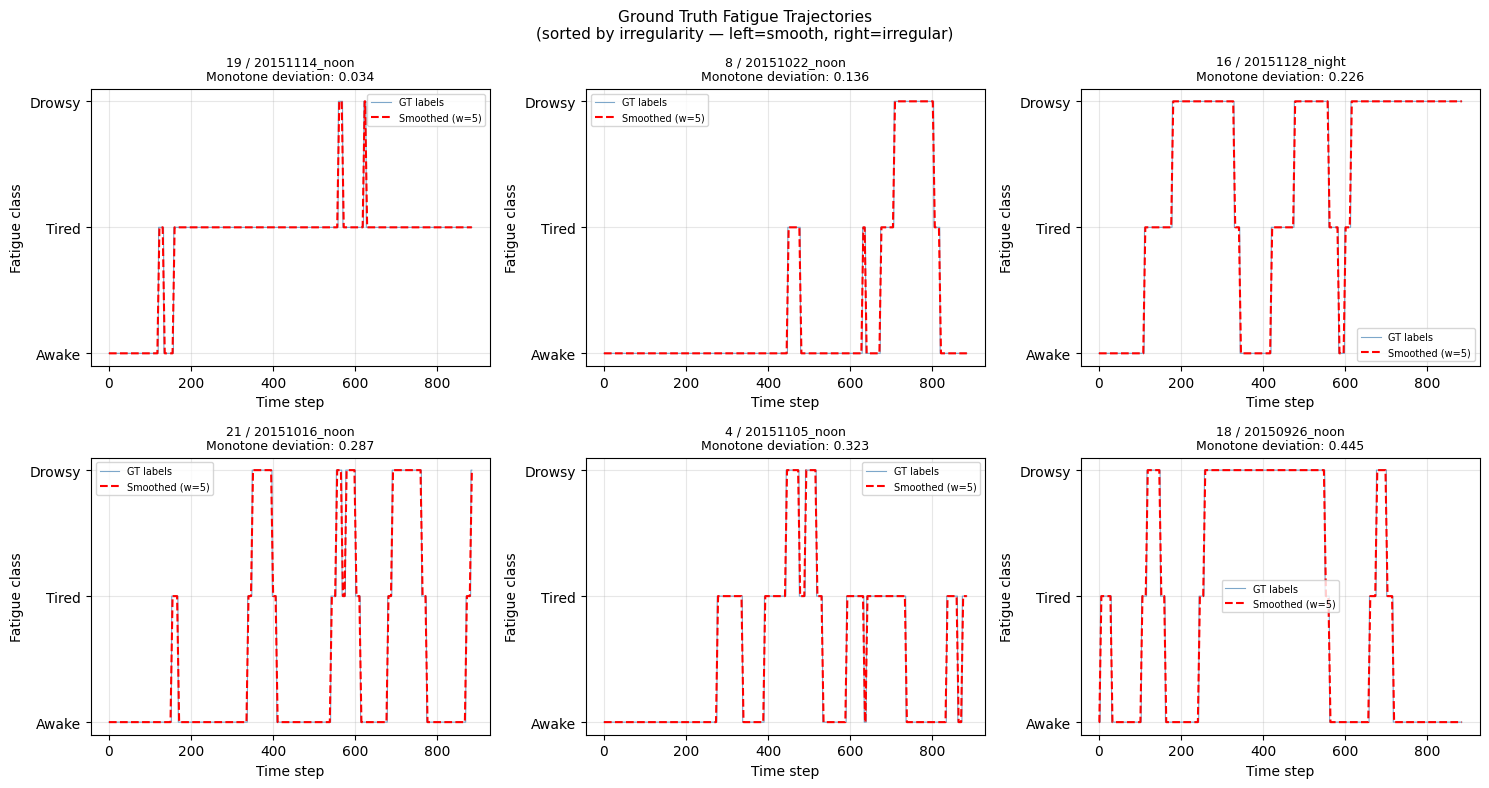

Saved: /kaggle/working/stage0_gt_trajectories.png


In [13]:
# ============================================================
# BLOCK 0.7: VISUALIZE REPRESENTATIVE TRAJECTORIES
# ============================================================
# Numbers alone are not enough. Plot 6 representative sessions
# to visually confirm what the trajectories look like.
# Pick sessions that span the range of irregularity scores.
# ============================================================

def plot_trajectory_grid(sessions, gt_df, n_examples=6):
    """Plot label trajectories for sessions spanning irregularity range."""
    # Sort by monotone_deviation and pick spread examples
    sorted_idx = gt_df['monotone_deviation'].argsort().values
    
    if len(sorted_idx) >= n_examples:
        # Pick evenly spaced examples across the sorted range
        selected_indices = np.linspace(0, len(sorted_idx)-1, 
                                       n_examples, dtype=int)
        selected_session_positions = sorted_idx[selected_indices]
    else:
        selected_session_positions = sorted_idx
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for plot_idx, sess_pos in enumerate(selected_session_positions):
        ax = axes[plot_idx]
        s = sessions[sess_pos]
        seq = s['labels_discrete']
        
        # Plot raw discrete trajectory
        ax.plot(seq, alpha=0.7, color='steelblue', linewidth=0.8, 
                label='GT labels')
        
        # Plot smoothed version (5-window moving average)
        if len(seq) > 5:
            smoothed = pd.Series(seq.astype(float)).rolling(5, 
                        center=True, min_periods=1).mean().values
            ax.plot(smoothed, color='red', linewidth=1.5, 
                    linestyle='--', label='Smoothed (w=5)')
        
        deviation = gt_df.iloc[sess_pos]['monotone_deviation']
        ax.set_title(f"{s['subject_id']} / {s['session_id']}\n"
                     f"Monotone deviation: {deviation:.3f}", fontsize=9)
        ax.set_xlabel('Time step')
        ax.set_ylabel('Fatigue class')
        ax.set_yticks([0, 1, 2])
        ax.set_yticklabels(['Awake', 'Tired', 'Drowsy'])
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Ground Truth Fatigue Trajectories\n'
                 '(sorted by irregularity — left=smooth, right=irregular)', 
                 fontsize=11)
    plt.tight_layout()
    plt.savefig('/kaggle/working/stage0_gt_trajectories.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: /kaggle/working/stage0_gt_trajectories.png")

plot_trajectory_grid(sessions, gt_df)

In [14]:
# Constants for SEED-VIG DE features
N_CHANNELS = 17
N_FREQ_BANDS = 5

In [15]:
import pickle

save_data = {
    'sessions': sessions,
    'gt_df': gt_df,
    'LABEL_TYPE': LABEL_TYPE,
    'N_CHANNELS': N_CHANNELS,
    'N_FREQ_BANDS': N_FREQ_BANDS,
}

with open('/kaggle/working/stage0_output.pkl', 'wb') as f:
    pickle.dump(save_data, f)

print("Saved successfully.")

Saved successfully.


In [16]:
import pickle

with open('/kaggle/working/stage0_output.pkl', 'rb') as f:
    stage0 = pickle.load(f)

print(f"Sessions: {len(stage0['sessions'])}")
print(f"Label type: {stage0['LABEL_TYPE']}")

Sessions: 23
Label type: continuous


# **STAGE 1**

In [17]:
# ============================================================
# STAGE 1: BASELINE MODEL TRAINING
# Notebook: stage1_baseline_training.ipynb
# ============================================================
# Train an MLP classifier on DE features under LOSO evaluation.
# Goal: NOT to maximize accuracy.
# Goal: To produce per-session prediction sequences for
#        temporal analysis in Stage 2.
# ============================================================

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix)
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# BLOCK 1.1: LOAD STAGE 0 OUTPUT
# ============================================================

with open('/kaggle/working/stage0_output.pkl', 'rb') as f:
    stage0 = pickle.load(f)

sessions    = stage0['sessions']
gt_df       = stage0['gt_df']
LABEL_TYPE  = stage0['LABEL_TYPE']
N_CHANNELS  = stage0['N_CHANNELS']
N_FREQ_BANDS = stage0['N_FREQ_BANDS']

print(f"Loaded {len(sessions)} sessions from Stage 0")
print(f"Feature dimensionality: {sessions[0]['features'].shape[1]}")
print(f"Label type: {LABEL_TYPE}")

# Verify data integrity
for s in sessions[:3]:
    assert len(s['features']) == len(s['labels_discrete']), \
        f"Length mismatch in session {s['subject_id']}"
print("Data integrity check: PASSED")

Loaded 23 sessions from Stage 0
Feature dimensionality: 85
Label type: continuous
Data integrity check: PASSED


In [18]:
# ============================================================
# BLOCK 1.2: FEATURE NORMALIZATION STRATEGY
# ============================================================
# CRITICAL METHODOLOGICAL DECISION:
# We normalize features using ONLY training data statistics.
# This simulates real deployment where test subject statistics
# are unknown. Using the full dataset mean/std would be
# data leakage and inflate accuracy estimates.
#
# Under LOSO: for each test subject, scaler is fit on all
# other subjects' data, then applied to test subject.
# ============================================================

def get_subject_groups(sessions):
    """
    Group session indices by subject_id.
    Returns dict: subject_id -> list of session indices
    """
    groups = {}
    for i, s in enumerate(sessions):
        sid = s['subject_id']
        if sid not in groups:
            groups[sid] = []
        groups[sid].append(i)
    return groups

subject_groups = get_subject_groups(sessions)
subject_ids = list(subject_groups.keys())

print(f"Subjects available for LOSO: {len(subject_ids)}")
print(f"Session distribution:")
for sid, indices in subject_groups.items():
    total_steps = sum(len(sessions[i]['labels_discrete']) for i in indices)
    print(f"  {sid}: {len(indices)} session(s), {total_steps} total time steps")

Subjects available for LOSO: 21
Session distribution:
  10: 1 session(s), 885 total time steps
  11: 1 session(s), 885 total time steps
  12: 1 session(s), 885 total time steps
  13: 1 session(s), 885 total time steps
  14: 1 session(s), 885 total time steps
  15: 1 session(s), 885 total time steps
  16: 1 session(s), 885 total time steps
  17: 1 session(s), 885 total time steps
  18: 1 session(s), 885 total time steps
  19: 1 session(s), 885 total time steps
  1: 1 session(s), 885 total time steps
  20: 1 session(s), 885 total time steps
  21: 1 session(s), 885 total time steps
  2: 1 session(s), 885 total time steps
  3: 1 session(s), 885 total time steps
  4: 2 session(s), 1770 total time steps
  5: 2 session(s), 1770 total time steps
  6: 1 session(s), 885 total time steps
  7: 1 session(s), 885 total time steps
  8: 1 session(s), 885 total time steps
  9: 1 session(s), 885 total time steps


In [19]:
# ============================================================
# BLOCK 1.3: LOSO TRAINING AND PREDICTION LOOP
# ============================================================
# For each subject as test:
#   1. Gather all other subjects' data as train
#   2. Fit scaler on train data only
#   3. Train MLP
#   4. Predict on all test sessions of left-out subject
#   5. Store complete prediction sequence (not just accuracy)
#
# WHY STORE COMPLETE SEQUENCES: This is the core requirement
# for Stage 2. We need the temporal prediction sequence, not
# just aggregate accuracy. Most papers only report accuracy.
# We need more.
# ============================================================

def build_train_test_split_loso(sessions, subject_groups, 
                                  test_subject_id):
    """
    Build train/test split for LOSO with one subject as test.
    
    Returns:
        X_train, y_train: concatenated training data
        test_sessions: list of dicts with features, labels for test subject
    """
    X_train_parts = []
    y_train_parts = []
    
    for sid, indices in subject_groups.items():
        if sid == test_subject_id:
            continue
        for idx in indices:
            X_train_parts.append(sessions[idx]['features'])
            y_train_parts.append(sessions[idx]['labels_discrete'])
    
    X_train = np.vstack(X_train_parts)
    y_train = np.concatenate(y_train_parts)
    
    test_sessions = []
    for idx in subject_groups[test_subject_id]:
        test_sessions.append({
            'subject_id': sessions[idx]['subject_id'],
            'session_id': sessions[idx]['session_id'],
            'features':   sessions[idx]['features'],
            'labels_gt':  sessions[idx]['labels_discrete'],
            'labels_raw': sessions[idx]['labels_raw'],
        })
    
    return X_train, y_train, test_sessions


def train_mlp_baseline(X_train, y_train):
    """
    Train MLP classifier.
    
    Architecture chosen to be:
    - Deep enough to capture EEG feature interactions
    - Not so complex that training takes >5 min on CPU
    - Reproducible (fixed random_state)
    
    This is not the best possible model. It is a defensible,
    reproducible baseline for temporal analysis purposes.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    
    model = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        solver='adam',
        alpha=1e-4,         # L2 regularization
        batch_size=256,
        learning_rate='adaptive',
        max_iter=100,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        verbose=False
    )
    model.fit(X_scaled, y_train)
    return model, scaler


# Main LOSO loop
print("Starting LOSO evaluation...")
print("This may take 10-30 minutes depending on dataset size.\n")

all_results = []  # one entry per test session

for fold_idx, test_subject in enumerate(subject_ids):
    print(f"  Fold {fold_idx+1}/{len(subject_ids)}: Test subject = {test_subject}")
    
    # Build split
    X_train, y_train, test_sessions = build_train_test_split_loso(
        sessions, subject_groups, test_subject
    )
    
    # Handle class imbalance by checking train distribution
    unique_classes, counts = np.unique(y_train, return_counts=True)
    class_dist = dict(zip(unique_classes, counts))
    
    # Train model
    model, scaler = train_mlp_baseline(X_train, y_train)
    
    # Predict on each test session SEPARATELY
    # CRITICAL: Do NOT concatenate test sessions before predicting.
    # We need per-session temporal sequences.
    for ts in test_sessions:
        X_test_scaled = scaler.transform(ts['features'])
        
        # Get hard predictions AND probabilities
        y_pred   = model.predict(X_test_scaled)
        y_proba  = model.predict_proba(X_test_scaled)  # shape: (T, n_classes)
        y_true   = ts['labels_gt']
        
        # Compute session-level accuracy
        acc = accuracy_score(y_true, y_pred)
        
        # Store complete temporal sequence
        result = {
            'subject_id':   ts['subject_id'],
            'session_id':   ts['session_id'],
            'y_true':       y_true,
            'y_pred':       y_pred,
            'y_proba':      y_proba,
            'accuracy':     acc,
            'n_timesteps':  len(y_true),
            'class_dist_train': class_dist,
        }
        all_results.append(result)
        print(f"    Session {ts['session_id']}: acc={acc:.3f}, T={len(y_true)}")

# Overall accuracy
all_acc = [r['accuracy'] for r in all_results]
print(f"\n{'='*50}")
print(f"LOSO Results Summary")
print(f"{'='*50}")
print(f"Mean accuracy: {np.mean(all_acc):.3f} ± {np.std(all_acc):.3f}")
print(f"Min accuracy:  {np.min(all_acc):.3f}")
print(f"Max accuracy:  {np.max(all_acc):.3f}")

# ============================================================
# ACCURACY BENCHMARK CHECK:
# For SEED-VIG 3-class LOSO, published baselines range:
#   ~55-75% accuracy depending on method
# Random baseline (given imbalance): ~33-50% (depends on distribution)
#
# If your accuracy is < 40%: something is likely wrong.
# Check: class distribution, feature normalization, label encoding
# 
# If accuracy is > 80%: possible data leakage. 
# Check: are you normalizing with test data stats?
# ============================================================

Starting LOSO evaluation...
This may take 10-30 minutes depending on dataset size.

  Fold 1/21: Test subject = 10
    Session 20151125_noon: acc=0.522, T=885
  Fold 2/21: Test subject = 11
    Session 20151024_night: acc=0.501, T=885
  Fold 3/21: Test subject = 12
    Session 20150928_noon: acc=0.417, T=885
  Fold 4/21: Test subject = 13
    Session 20150929_noon: acc=0.281, T=885
  Fold 5/21: Test subject = 14
    Session 20151014_night: acc=0.452, T=885
  Fold 6/21: Test subject = 15
    Session 20151126_night: acc=0.194, T=885
  Fold 7/21: Test subject = 16
    Session 20151128_night: acc=0.727, T=885
  Fold 8/21: Test subject = 17
    Session 20150925_noon: acc=0.103, T=885
  Fold 9/21: Test subject = 18
    Session 20150926_noon: acc=0.495, T=885
  Fold 10/21: Test subject = 19
    Session 20151114_noon: acc=0.262, T=885
  Fold 11/21: Test subject = 1
    Session 20151124_noon_2: acc=0.723, T=885
  Fold 12/21: Test subject = 20
    Session 20151129_night: acc=0.221, T=885
  Fold 

Overall classification report (all sessions):
              precision    recall  f1-score   support

       Awake      0.390     0.365     0.377      7405
       Tired      0.468     0.452     0.460      8901
      Drowsy      0.345     0.411     0.375      4049

    accuracy                          0.412     20355
   macro avg      0.401     0.409     0.404     20355
weighted avg      0.415     0.412     0.413     20355



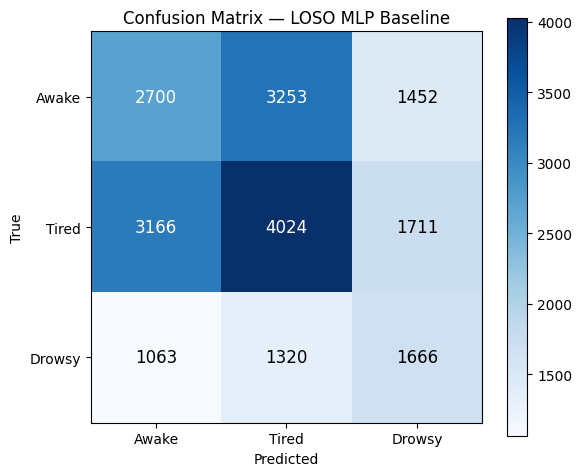


Drowsy class recall: 0.411


In [20]:
# ============================================================
# BLOCK 1.4: PER-CLASS PERFORMANCE AUDIT
# ============================================================
# Aggregate accuracy hides important failure modes.
# A model that always predicts "awake" can achieve 50%+ accuracy
# on an imbalanced dataset while being useless for fatigue detection.
#
# We MUST check per-class recall, especially for class 2 (drowsy).
# In deployment, missing drowsiness is the safety-critical failure.
# ============================================================

# Concatenate all predictions for overall classification report
y_all_true = np.concatenate([r['y_true'] for r in all_results])
y_all_pred = np.concatenate([r['y_pred'] for r in all_results])

print("Overall classification report (all sessions):")
print(classification_report(y_all_true, y_all_pred,
                             target_names=['Awake', 'Tired', 'Drowsy'],
                             digits=3))

# Confusion matrix
cm = confusion_matrix(y_all_true, y_all_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_xticklabels(['Awake','Tired','Drowsy'])
ax.set_yticklabels(['Awake','Tired','Drowsy'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — LOSO MLP Baseline')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center', 
                fontsize=12, color='white' if cm[i,j] > cm.max()*0.5 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('/kaggle/working/stage1_confusion_matrix.png', dpi=150)
plt.show()

# ============================================================
# FLAG: If Drowsy (class 2) recall < 0.30, the model has
# essentially failed to detect the most critical state.
# This may itself be a research finding worth noting —
# but it complicates temporal consistency analysis because
# the model may simply never predict class 2.
# ============================================================

drowsy_recall = cm[2,2] / cm[2,:].sum() if cm[2,:].sum() > 0 else 0
print(f"\nDrowsy class recall: {drowsy_recall:.3f}")
if drowsy_recall < 0.30:
    print("⚠ WARNING: Model rarely predicts Drowsy class.")
    print("  Temporal 'consistency' may be trivially achieved by")
    print("  never predicting class 2. Note this for Stage 2.")

In [21]:
import pickle, numpy as np
with open('/kaggle/working/stage0_output.pkl', 'rb') as f:
    stage0 = pickle.load(f)

sessions = stage0['sessions']
all_raw = np.concatenate([s['labels_raw'] for s in sessions])

print(f"PERCLOS distribution across all {len(all_raw)} timesteps:")
print(f"  Min:    {all_raw.min():.4f}")
print(f"  Max:    {all_raw.max():.4f}")
print(f"  Mean:   {all_raw.mean():.4f}")
print(f"  Median: {np.median(all_raw):.4f}")
print(f"  Std:    {all_raw.std():.4f}")

thresholds = [(0.35, 0.70), (0.30, 0.60), (0.25, 0.50)]
for low, high in thresholds:
    c0 = (all_raw < low).mean()
    c1 = ((all_raw >= low) & (all_raw < high)).mean()
    c2 = (all_raw >= high).mean()
    print(f"\n  Thresholds ({low}, {high}):")
    print(f"    Awake:  {c0*100:.1f}%")
    print(f"    Tired:  {c1*100:.1f}%")
    print(f"    Drowsy: {c2*100:.1f}%")

PERCLOS distribution across all 20355 timesteps:
  Min:    0.0221
  Max:    1.0000
  Mean:   0.4667
  Median: 0.4185
  Std:    0.2688

  Thresholds (0.35, 0.7):
    Awake:  36.4%
    Tired:  43.7%
    Drowsy: 19.9%

  Thresholds (0.3, 0.6):
    Awake:  28.3%
    Tired:  46.7%
    Drowsy: 25.0%

  Thresholds (0.25, 0.5):
    Awake:  22.5%
    Tired:  42.8%
    Drowsy: 34.7%


In [22]:
# ============================================================
# BLOCK 1.5: SAVE ALL RESULTS FOR STAGE 2
# ============================================================

stage1_output = {
    'all_results': all_results,
    'subject_ids': subject_ids,
    'subject_groups': subject_groups,
    'overall_accuracy': np.mean(all_acc),
    'y_all_true': y_all_true,
    'y_all_pred': y_all_pred,
}

with open('/kaggle/working/stage1_output.pkl', 'wb') as f:
    pickle.dump(stage1_output, f)

print(f"Saved {len(all_results)} session result records to stage1_output.pkl")
print(f"\nStage 1 Complete.")
print(f"Overall LOSO accuracy: {np.mean(all_acc):.3f}")
print(f"Report these numbers before proceeding to Stage 2:")
print(f"  1. Overall accuracy")
print(f"  2. Per-class recall (Awake / Tired / Drowsy)")
print(f"  3. Any sessions where accuracy < 0.35")

Saved 23 session result records to stage1_output.pkl

Stage 1 Complete.
Overall LOSO accuracy: 0.412
Report these numbers before proceeding to Stage 2:
  1. Overall accuracy
  2. Per-class recall (Awake / Tired / Drowsy)
  3. Any sessions where accuracy < 0.35


# **STAGE 2**

In [33]:
# ============================================================
# STAGE 2: TEMPORAL INCONSISTENCY QUANTIFICATION
# Notebook: stage2_temporal_analysis.ipynb
# ============================================================

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr, wilcoxon, mannwhitneyu
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings('ignore')

# Load both stages
with open('/kaggle/working/stage0_output.pkl', 'rb') as f:
    stage0 = pickle.load(f)
with open('/kaggle/working/stage1_output.pkl', 'rb') as f:
    stage1 = pickle.load(f)

sessions     = stage0['sessions']
gt_df        = stage0['gt_df']
all_results  = stage1['all_results']

print(f"Sessions to analyze: {len(all_results)}")

Sessions to analyze: 23


In [34]:
# ============================================================
# BLOCK 2.1: DEFINE THE TEMPORAL INCONSISTENCY METRICS SUITE
# ============================================================
# We define FOUR metrics. Each captures a different aspect
# of temporal inconsistency. We compute all four on:
#   (A) Ground truth sequences   ← upper bound on "natural" noise
#   (B) Model predictions        ← what we're measuring
#   (C) Post-processed predictions (Stage 3 will use this)
#
# METRIC 1: Reversal Rate (RR)
#   Fraction of consecutive prediction pairs where the
#   fatigue class decreases. High RR = model frequently
#   predicts lower fatigue AFTER predicting higher fatigue.
#   Simple, interpretable, comparable to published work.
#
# METRIC 2: Temporal Deviation Score (TDS)
#   Compare the actual prediction sequence with the "ideal"
#   monotonically non-decreasing sequence closest to it
#   (in L1 norm). TDS = L1(prediction, nearest_monotone) / T.
#   Captures cumulative drift, not just adjacent steps.
#
# METRIC 3: Trajectory Correlation (TC)
#   Spearman correlation between time index (1..T) and
#   predicted class. For a genuine fatigue session, this
#   should be positive and reasonably high.
#   A model that randomly fluctuates will have TC ≈ 0.
#
# METRIC 4: Safety-Critical Reversal Count (SCRC)
#   Count of "Drowsy → Awake" or "Drowsy → Tired" transitions
#   in the prediction sequence. These are the failures that
#   matter in deployment: the model says drowsy, then says
#   awake one window later.
# ============================================================

def nearest_monotone_nondecreasing(seq):
    """
    Compute the nearest non-decreasing sequence to seq in L1 norm.
    Uses isotonic regression (pool adjacent violators algorithm).
    
    This gives us the 'best case' smooth version to compare against.
    """
    from sklearn.isotonic import IsotonicRegression
    ir = IsotonicRegression(increasing=True)
    t = np.arange(len(seq))
    smooth = ir.fit_transform(t, seq.astype(float))
    return smooth


def compute_temporal_metrics(pred_sequence, gt_sequence=None):
    """
    Compute full suite of temporal inconsistency metrics.
    
    Args:
        pred_sequence: np.array of integer predictions (0, 1, 2)
        gt_sequence:   np.array of ground truth labels (optional)
    
    Returns:
        dict of metric name -> value
    """
    pred = np.array(pred_sequence)
    T    = len(pred)
    
    if T < 5:
        return None
    
    # --- METRIC 1: Reversal Rate ---
    diffs = np.diff(pred)
    rr    = (diffs < 0).mean()
    
    # --- METRIC 2: Temporal Deviation Score ---
    nearest_mono = nearest_monotone_nondecreasing(pred)
    tds = np.mean(np.abs(pred.astype(float) - nearest_mono)) / 2.0
    # Divide by 2 (max class range) to normalize to [0,1]
    
    # --- METRIC 3: Trajectory Correlation ---
    time_index = np.arange(T)
    tc, tc_pval = spearmanr(time_index, pred)
    # Positive TC = predictions tend to increase over time (correct)
    # Negative/zero TC = no temporal trend
    
    # --- METRIC 4: Safety-Critical Reversal Count ---
    # Count transitions where prediction drops FROM class 2 (drowsy)
    scrc_total = 0
    for i in range(len(pred) - 1):
        if pred[i] == 2 and pred[i+1] < 2:
            scrc_total += 1
    scrc_rate = scrc_total / T  # normalized
    
    # --- METRIC 5: Maximum Consecutive Inconsistency (MCI) ---
    # Longest run of consecutive decreasing steps
    # This captures whether inconsistency is isolated or sustained
    max_dec_run = 0
    cur_dec_run = 0
    for d in diffs:
        if d < 0:
            cur_dec_run += 1
            max_dec_run = max(max_dec_run, cur_dec_run)
        else:
            cur_dec_run = 0
    
    result = {
        'reversal_rate':         rr,
        'temporal_deviation_score': tds,
        'trajectory_correlation': tc,
        'tc_pvalue':             tc_pval,
        'scrc_rate':             scrc_rate,
        'scrc_count':            scrc_total,
        'max_consecutive_inconsistency': max_dec_run,
        'n_timesteps':           T,
    }
    
    # If ground truth provided, compute RELATIVE inconsistency
    # (model inconsistency vs ground truth inconsistency)
    if gt_sequence is not None:
        gt = np.array(gt_sequence)
        gt_diffs = np.diff(gt)
        gt_rr    = (gt_diffs < 0).mean()
        gt_nearest_mono = nearest_monotone_nondecreasing(gt)
        gt_tds = np.mean(np.abs(gt.astype(float) - gt_nearest_mono)) / 2.0
        gt_tc, _ = spearmanr(np.arange(len(gt)), gt)
        
        # EXCESS inconsistency: model beyond ground truth
        result['excess_reversal_rate']    = max(0, rr - gt_rr)
        result['excess_tds']              = max(0, tds - gt_tds)
        result['gt_reversal_rate']        = gt_rr
        result['gt_tds']                  = gt_tds
        result['gt_trajectory_correlation'] = gt_tc
    
    return result


# Test the function on a simple case first
test_pred_bad  = np.array([0, 2, 0, 2, 0, 1, 2, 0, 1, 0])
test_pred_good = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2, 2])
test_gt        = np.array([0, 0, 1, 1, 1, 2, 2, 2, 2, 2])

m_bad  = compute_temporal_metrics(test_pred_bad,  test_gt)
m_good = compute_temporal_metrics(test_pred_good, test_gt)

print("Sanity check on known sequences:")
print(f"\nBad predictions (random): {test_pred_bad}")
print(f"  Reversal rate:          {m_bad['reversal_rate']:.3f}  (should be ~0.55)")
print(f"  TDS:                    {m_bad['temporal_deviation_score']:.3f}")
print(f"  Trajectory correlation: {m_bad['trajectory_correlation']:.3f}  (should be ~0)")

print(f"\nGood predictions (monotone): {test_pred_good}")
print(f"  Reversal rate:          {m_good['reversal_rate']:.3f}  (should be 0.00)")
print(f"  TDS:                    {m_good['temporal_deviation_score']:.3f}  (should be 0.00)")
print(f"  Trajectory correlation: {m_good['trajectory_correlation']:.3f}  (should be ~1.0)")

# ============================================================
# If sanity check values are wrong, debug compute_temporal_metrics
# before running on real data.
# ============================================================

Sanity check on known sequences:

Bad predictions (random): [0 2 0 2 0 1 2 0 1 0]
  Reversal rate:          0.444  (should be ~0.55)
  TDS:                    0.356
  Trajectory correlation: -0.092  (should be ~0)

Good predictions (monotone): [0 0 0 1 1 1 2 2 2 2]
  Reversal rate:          0.000  (should be 0.00)
  TDS:                    0.000  (should be 0.00)
  Trajectory correlation: 0.944  (should be ~1.0)


In [35]:
# ============================================================
# BLOCK 2.2: COMPUTE METRICS ON ALL SESSIONS
# ============================================================
# Compute all metrics for:
#   (A) Ground truth sequences
#   (B) Model predictions
# Side by side, so we can compare.
# ============================================================

session_metrics = []

for result in all_results:
    y_pred  = result['y_pred']
    y_true  = result['y_true']
    
    # Compute metrics for predictions
    pred_metrics = compute_temporal_metrics(y_pred, y_true)
    if pred_metrics is None:
        continue
    
    # Compute metrics for ground truth (to establish baseline noise level)
    gt_metrics_local = compute_temporal_metrics(y_true)
    
    entry = {
        'subject_id':   result['subject_id'],
        'session_id':   result['session_id'],
        'accuracy':     result['accuracy'],
        'n_timesteps':  result['n_timesteps'],
    }
    
    # Add prediction metrics with prefix
    for k, v in pred_metrics.items():
        entry[f'pred_{k}'] = v
    
    # Add GT metrics with prefix
    for k, v in gt_metrics_local.items():
        entry[f'gt_{k}'] = v
    
    session_metrics.append(entry)

metrics_df = pd.DataFrame(session_metrics)
print(f"Computed metrics for {len(metrics_df)} sessions")
print("\nColumn names:")
print([c for c in metrics_df.columns if c.startswith('pred_')])

Computed metrics for 23 sessions

Column names:
['pred_reversal_rate', 'pred_temporal_deviation_score', 'pred_trajectory_correlation', 'pred_tc_pvalue', 'pred_scrc_rate', 'pred_scrc_count', 'pred_max_consecutive_inconsistency', 'pred_n_timesteps', 'pred_excess_reversal_rate', 'pred_excess_tds', 'pred_gt_reversal_rate', 'pred_gt_tds', 'pred_gt_trajectory_correlation']


In [36]:
# ============================================================
# BLOCK 2.3: THE CORE COMPARISON — MODEL VS GROUND TRUTH
# ============================================================
# This is the heart of the research question:
# Are model predictions MORE temporally inconsistent than
# the ground truth labels?
#
# If YES: model adds inconsistency beyond what labels demand.
#   This is a real model failure, not just label noise.
#
# If NO: model inconsistency tracks label inconsistency.
#   Then the "problem" is really a data quality problem,
#   not a model problem.
#
# We test this with the Wilcoxon signed-rank test
# (non-parametric, appropriate for small n).
# ============================================================

from scipy.stats import wilcoxon

print("=" * 60)
print("CORE COMPARISON: MODEL vs GROUND TRUTH INCONSISTENCY")
print("=" * 60)

metrics_to_compare = [
    ('reversal_rate',         'Reversal Rate', 
     'Higher = more inconsistency. Bad.'),
    ('temporal_deviation_score', 'Temporal Deviation Score',
     'Higher = further from smooth. Bad.'),
    ('trajectory_correlation', 'Trajectory Correlation',
     'Higher = better temporal trend. Good.'),
]

comparison_results = {}

for metric_key, metric_name, interpretation in metrics_to_compare:
    pred_vals = metrics_df[f'pred_{metric_key}'].dropna().values
    gt_vals   = metrics_df[f'gt_{metric_key}'].dropna().values
    
    # Ensure aligned
    n = min(len(pred_vals), len(gt_vals))
    pred_vals = pred_vals[:n]
    gt_vals   = gt_vals[:n]
    
    # Test if model is significantly WORSE than GT
    # Wilcoxon signed-rank test (paired, non-parametric)
    if metric_key == 'trajectory_correlation':
        # For TC, model should be HIGHER. Test if GT > model (bad).
        try:
            stat, pval = wilcoxon(gt_vals, pred_vals, alternative='greater')
        except:
            stat, pval = float('nan'), float('nan')
        direction = 'GT > Model (model lacks temporal trend)'
    else:
        # For RR and TDS, model should be LOWER. Test if model > GT (bad).
        try:
            stat, pval = wilcoxon(pred_vals, gt_vals, alternative='greater')
        except:
            stat, pval = float('nan'), float('nan')
        direction = 'Model > GT (model adds inconsistency)'
    
    mean_pred = np.nanmean(pred_vals)
    mean_gt   = np.nanmean(gt_vals)
    effect    = mean_pred - mean_gt
    
    comparison_results[metric_key] = {
        'mean_pred': mean_pred, 'mean_gt': mean_gt,
        'effect': effect, 'pval': pval
    }
    
    print(f"\n{metric_name} ({interpretation})")
    print(f"  Model predictions: {mean_pred:.4f} ± {np.nanstd(pred_vals):.4f}")
    print(f"  Ground truth:      {mean_gt:.4f} ± {np.nanstd(gt_vals):.4f}")
    print(f"  Difference:        {effect:+.4f}")
    print(f"  Wilcoxon p-value:  {pval:.4f}  ({direction})")
    
    if not np.isnan(pval):
        if pval < 0.05:
            print(f"  ✓ SIGNIFICANT: Model is meaningfully more inconsistent than GT")
        elif pval < 0.10:
            print(f"  ~ MARGINAL: Trend present but not fully significant")
        else:
            print(f"  ✗ NOT SIGNIFICANT: Model inconsistency tracks GT noise")

print("\n")
print("SAFETY-CRITICAL REVERSALS (Drowsy → non-Drowsy):")
pred_scrc = metrics_df['pred_scrc_rate'].mean()
print(f"  Model: {pred_scrc:.4f} safety-critical reversals per timestep")
print(f"  In a 300-step session, this means {int(pred_scrc*300)} dangerous flip events")

CORE COMPARISON: MODEL vs GROUND TRUTH INCONSISTENCY

Reversal Rate (Higher = more inconsistency. Bad.)
  Model predictions: 0.0190 ± 0.0115
  Ground truth:      0.0078 ± 0.0041
  Difference:        +0.0112
  Wilcoxon p-value:  0.0002  (Model > GT (model adds inconsistency))
  ✓ SIGNIFICANT: Model is meaningfully more inconsistent than GT

Temporal Deviation Score (Higher = further from smooth. Bad.)
  Model predictions: 0.1543 ± 0.0830
  Ground truth:      0.1874 ± 0.1013
  Difference:        -0.0331
  Wilcoxon p-value:  0.7098  (Model > GT (model adds inconsistency))
  ✗ NOT SIGNIFICANT: Model inconsistency tracks GT noise

Trajectory Correlation (Higher = better temporal trend. Good.)
  Model predictions: 0.0528 ± 0.2287
  Ground truth:      0.2183 ± 0.3357
  Difference:        -0.1655
  Wilcoxon p-value:  0.0042  (GT > Model (model lacks temporal trend))
  ✓ SIGNIFICANT: Model is meaningfully more inconsistent than GT


SAFETY-CRITICAL REVERSALS (Drowsy → non-Drowsy):
  Model: 0.00

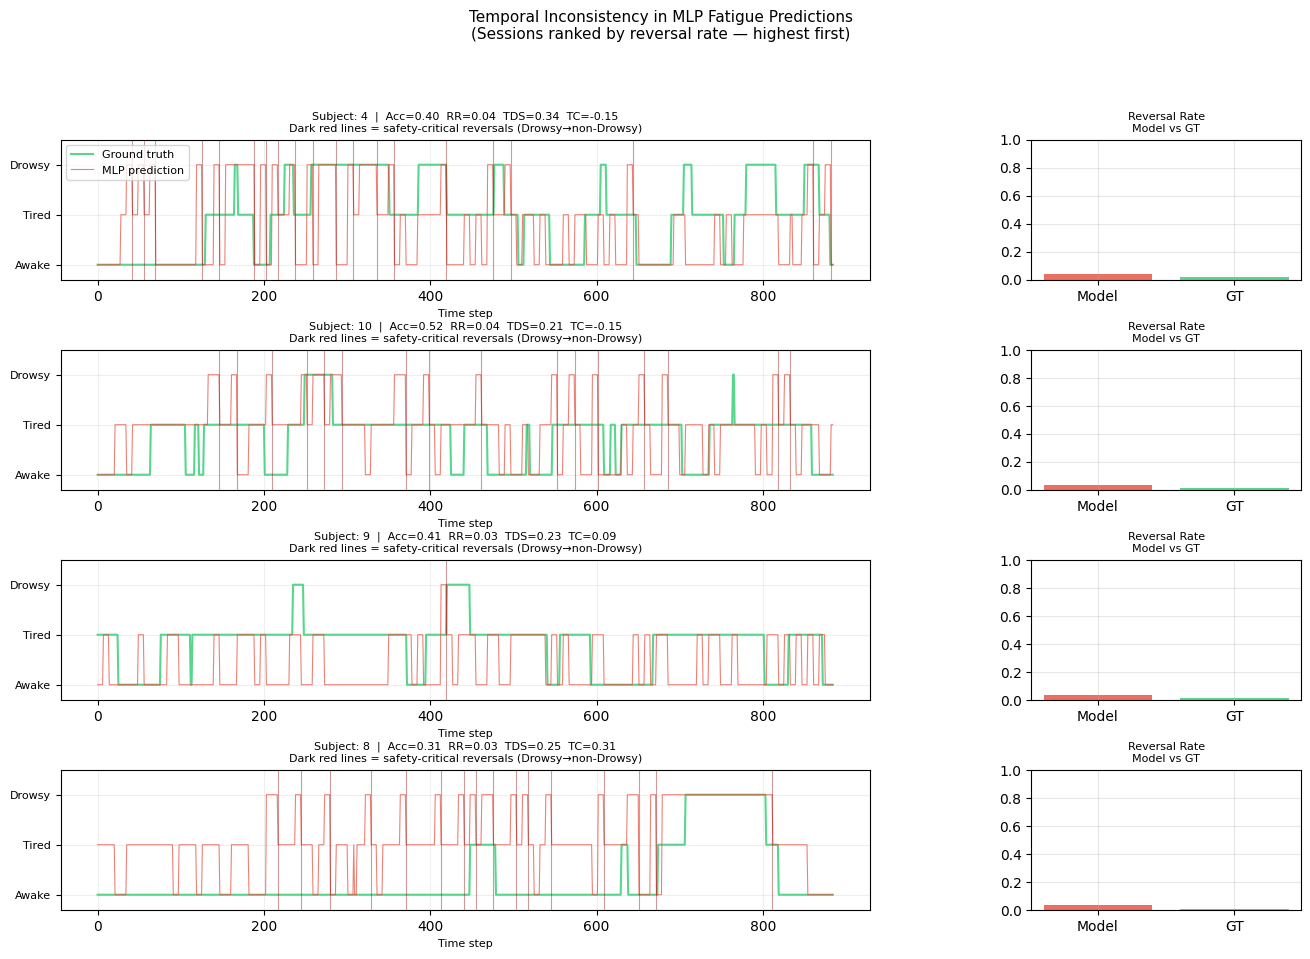

Saved: stage2_inconsistency_visualization.png


In [37]:
# ============================================================
# BLOCK 2.4: VISUALIZATION — THE MOST IMPORTANT FIGURE
# ============================================================
# Generate the figure that will go in the paper (if validated).
# Show: 4 representative sessions with GT vs prediction.
# Select sessions that show the STRONGEST inconsistency
# to demonstrate the phenomenon most clearly.
# ============================================================

def plot_prediction_vs_gt(results_list, metrics_df, n_examples=4):
    """
    Plot GT vs predicted sequences for sessions with highest
    temporal inconsistency, to visualize the phenomenon.
    """
    # Select sessions with highest reversal rate
    metrics_sorted = metrics_df.sort_values('pred_reversal_rate', 
                                             ascending=False)
    top_sessions = metrics_sorted.head(n_examples)
    
    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(n_examples, 2, 
                           width_ratios=[3, 1], 
                           hspace=0.5, wspace=0.3)
    
    result_dict = {(r['subject_id'], r['session_id']): r 
                   for r in results_list}
    
    for plot_idx, (_, row) in enumerate(top_sessions.iterrows()):
        key = (row['subject_id'], row['session_id'])
        if key not in result_dict:
            continue
        r = result_dict[key]
        
        ax_main = fig.add_subplot(gs[plot_idx, 0])
        ax_bar  = fig.add_subplot(gs[plot_idx, 1])
        
        T    = len(r['y_true'])
        time = np.arange(T)
        
        # Plot GT
        ax_main.plot(time, r['y_true'], 
                     color='#2ecc71', linewidth=1.5, 
                     alpha=0.8, label='Ground truth')
        
        # Plot raw prediction
        ax_main.plot(time, r['y_pred'], 
                     color='#e74c3c', linewidth=0.8, 
                     alpha=0.7, label='MLP prediction')
        
        # Highlight safety-critical reversals (Drowsy→non-Drowsy)
        for t in range(len(r['y_pred'])-1):
            if r['y_pred'][t] == 2 and r['y_pred'][t+1] < 2:
                ax_main.axvline(x=t+0.5, color='darkred', 
                                alpha=0.4, linewidth=0.8)
        
        rr  = row['pred_reversal_rate']
        tds = row['pred_temporal_deviation_score']
        tc  = row['pred_trajectory_correlation']
        acc = row['accuracy']
        
        ax_main.set_ylim(-0.3, 2.5)
        ax_main.set_yticks([0, 1, 2])
        ax_main.set_yticklabels(['Awake', 'Tired', 'Drowsy'], fontsize=8)
        ax_main.set_xlabel('Time step', fontsize=8)
        ax_main.set_title(
            f"Subject: {row['subject_id']}  |  "
            f"Acc={acc:.2f}  RR={rr:.2f}  TDS={tds:.2f}  TC={tc:.2f}\n"
            f"Dark red lines = safety-critical reversals (Drowsy→non-Drowsy)",
            fontsize=8
        )
        if plot_idx == 0:
            ax_main.legend(fontsize=8, loc='upper left')
        ax_main.grid(True, alpha=0.2)
        
        # Bar chart: metrics comparison
        metric_vals = [
            row['pred_reversal_rate'],
            row['gt_reversal_rate'] if 'gt_reversal_rate' in row else 0,
        ]
        ax_bar.bar(['Model', 'GT'], metric_vals, 
                   color=['#e74c3c', '#2ecc71'], alpha=0.8)
        ax_bar.set_title('Reversal Rate\nModel vs GT', fontsize=8)
        ax_bar.set_ylim(0, 1)
        ax_bar.grid(True, alpha=0.3)
    
    plt.suptitle('Temporal Inconsistency in MLP Fatigue Predictions\n'
                 '(Sessions ranked by reversal rate — highest first)',
                 fontsize=11, y=1.01)
    plt.savefig('/kaggle/working/stage2_inconsistency_visualization.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: stage2_inconsistency_visualization.png")

plot_prediction_vs_gt(all_results, metrics_df)

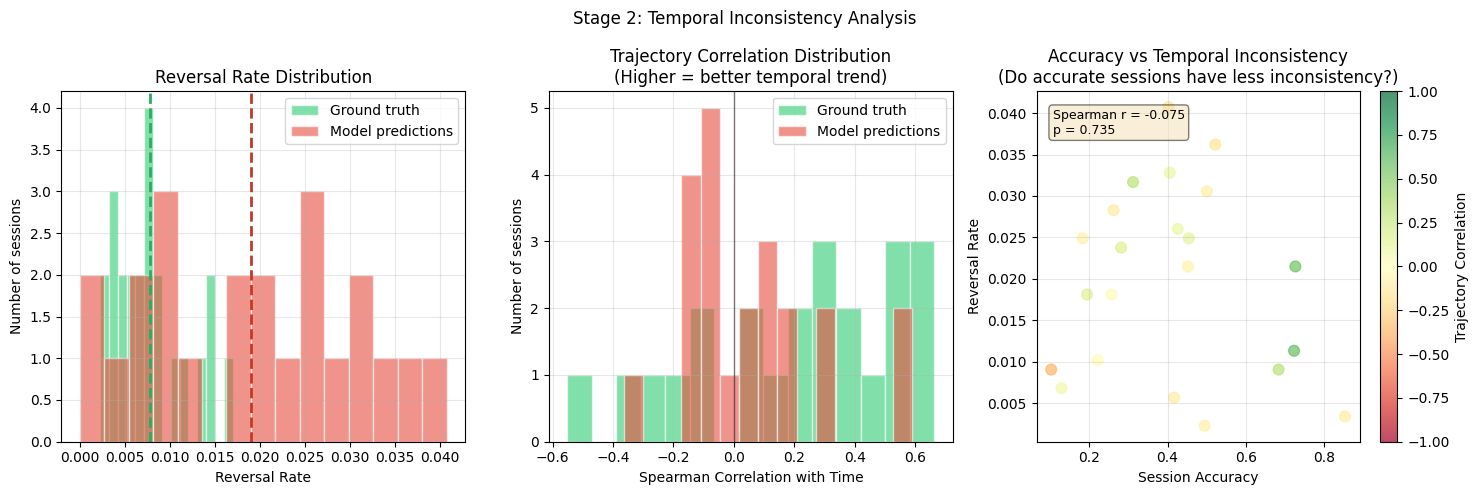


Correlation between session accuracy and reversal rate:
  Spearman r = -0.075, p = 0.7349
  ✓ Weak correlation: inconsistency is DISTINCT from inaccuracy.
    This is important. You can argue these are separate failure modes.


In [38]:
# ============================================================
# BLOCK 2.5: DISTRIBUTION ANALYSIS
# ============================================================
# Show that temporal inconsistency is not just from a few
# outlier sessions — it occurs broadly across subjects.
# This is important for a paper: the problem must be systemic.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Reversal Rate distribution
ax = axes[0]
ax.hist(metrics_df['gt_reversal_rate'], bins=15, alpha=0.6, 
        color='#2ecc71', label='Ground truth', edgecolor='white')
ax.hist(metrics_df['pred_reversal_rate'], bins=15, alpha=0.6, 
        color='#e74c3c', label='Model predictions', edgecolor='white')
ax.axvline(metrics_df['gt_reversal_rate'].mean(), 
           color='#27ae60', linestyle='--', linewidth=2)
ax.axvline(metrics_df['pred_reversal_rate'].mean(), 
           color='#c0392b', linestyle='--', linewidth=2)
ax.set_xlabel('Reversal Rate')
ax.set_ylabel('Number of sessions')
ax.set_title('Reversal Rate Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Trajectory Correlation
ax = axes[1]
ax.hist(metrics_df['gt_trajectory_correlation'], bins=15, alpha=0.6,
        color='#2ecc71', label='Ground truth', edgecolor='white')
ax.hist(metrics_df['pred_trajectory_correlation'], bins=15, alpha=0.6,
        color='#e74c3c', label='Model predictions', edgecolor='white')
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_xlabel('Spearman Correlation with Time')
ax.set_ylabel('Number of sessions')
ax.set_title('Trajectory Correlation Distribution\n(Higher = better temporal trend)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Scatter — Accuracy vs Reversal Rate
ax = axes[2]
sc = ax.scatter(metrics_df['accuracy'], 
                metrics_df['pred_reversal_rate'],
                c=metrics_df['pred_trajectory_correlation'],
                cmap='RdYlGn', s=60, alpha=0.7, vmin=-1, vmax=1)
plt.colorbar(sc, ax=ax, label='Trajectory Correlation')
ax.set_xlabel('Session Accuracy')
ax.set_ylabel('Reversal Rate')
ax.set_title('Accuracy vs Temporal Inconsistency\n(Do accurate sessions have less inconsistency?)')
ax.grid(True, alpha=0.3)

# Compute and annotate correlation
corr, pval = spearmanr(metrics_df['accuracy'], 
                        metrics_df['pred_reversal_rate'])
ax.text(0.05, 0.95, f"Spearman r = {corr:.3f}\np = {pval:.3f}",
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Stage 2: Temporal Inconsistency Analysis', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/stage2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# KEY QUESTION FROM THIS PLOT:
# Is there a negative correlation between accuracy and reversal rate?
# If yes: inconsistency is simply inaccuracy. Not novel.
# If no: inconsistency is a distinct failure mode from inaccuracy.
#         THIS IS THE PUBLISHABLE CLAIM.
# ============================================================

print(f"\nCorrelation between session accuracy and reversal rate:")
print(f"  Spearman r = {corr:.3f}, p = {pval:.4f}")
if abs(corr) < 0.40:
    print("  ✓ Weak correlation: inconsistency is DISTINCT from inaccuracy.")
    print("    This is important. You can argue these are separate failure modes.")
elif corr < -0.70:
    print("  ✗ Strong negative correlation: inconsistency tracks inaccuracy.")
    print("    Hard to argue these are separate phenomena.")
else:
    print("  ~ Moderate correlation: some overlap, some independence.")
    print("    Nuanced argument possible.")

In [39]:
# ============================================================

# BLOCK 2.6: SAVE STAGE 2 RESULTS

# ============================================================



stage2_output = {

    'metrics_df':          metrics_df,

    'comparison_results':  comparison_results,

}



with open('/kaggle/working/stage2_output.pkl', 'wb') as f:

    pickle.dump(stage2_output, f)



print("Stage 2 complete. Report these numbers to me:")

print(f"\n1. Mean reversal rate (model): {metrics_df['pred_reversal_rate'].mean():.4f}")

print(f"2. Mean reversal rate (GT):    {metrics_df['gt_reversal_rate'].mean():.4f}")

print(f"3. Wilcoxon p-value (RR):      {comparison_results.get('reversal_rate', {}).get('pval', 'N/A')}")

print(f"4. Mean trajectory corr (model): {metrics_df['pred_trajectory_correlation'].mean():.4f}")

print(f"5. Mean trajectory corr (GT):    {metrics_df['gt_trajectory_correlation'].mean():.4f}")

print(f"6. Accuracy vs RR correlation: {corr:.4f} (p={pval:.4f})")

print(f"7. Safety-critical reversal rate: {metrics_df['pred_scrc_rate'].mean():.4f}")

Stage 2 complete. Report these numbers to me:

1. Mean reversal rate (model): 0.0190
2. Mean reversal rate (GT):    0.0078
3. Wilcoxon p-value (RR):      0.00017718175366958843
4. Mean trajectory corr (model): 0.0528
5. Mean trajectory corr (GT):    0.2037
6. Accuracy vs RR correlation: -0.0747 (p=0.7349)
7. Safety-critical reversal rate: 0.0096


In [41]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 1.4 MB/s eta 0:00:0000:010:01


# STAGE 3

In [42]:
# ============================================================
# STAGE 3: SURVIVABILITY TEST
# Notebook: stage3_survivability.ipynb
# ============================================================
# The research direction is only defensible if temporal
# inconsistency SURVIVES naive post-processing.
# We test three post-processing strategies:
#   A. Majority vote (sliding window)
#   B. Moving average + threshold
#   C. Viterbi decoding (HMM) — strongest naive baseline
#
# If ALL THREE eliminate inconsistency while maintaining
# accuracy → there is no paper. Pivot immediately.
#
# If C (Viterbi) substantially reduces inconsistency but
# at a cost to accuracy → there is a tradeoff story.
#
# If inconsistency persists after all three → strong paper.
# ============================================================

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, spearmanr
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')

# Load all previous outputs
with open('/kaggle/working/stage0_output.pkl', 'rb') as f:
    stage0 = pickle.load(f)
with open('/kaggle/working/stage1_output.pkl', 'rb') as f:
    stage1 = pickle.load(f)
with open('/kaggle/working/stage2_output.pkl', 'rb') as f:
    stage2 = pickle.load(f)

all_results  = stage1['all_results']
metrics_df   = stage2['metrics_df']

print("Loaded all previous stage outputs.")
print(f"Sessions to analyze: {len(all_results)}")

Loaded all previous stage outputs.
Sessions to analyze: 23


In [43]:
# ============================================================
# BLOCK 3.1: INSTALL DEPENDENCIES
# ============================================================

import subprocess
result = subprocess.run(['pip', 'install', 'hmmlearn', '-q'], 
                        capture_output=True, text=True)
print(result.stdout if result.stdout else "hmmlearn ready")

from hmmlearn import hmm

# Re-import compute_temporal_metrics from Stage 2
# (copy the function here for self-contained execution)

from sklearn.isotonic import IsotonicRegression

def nearest_monotone_nondecreasing(seq):
    ir = IsotonicRegression(increasing=True)
    t  = np.arange(len(seq))
    return ir.fit_transform(t, seq.astype(float))

def compute_temporal_metrics(pred_sequence, gt_sequence=None):
    pred = np.array(pred_sequence)
    T    = len(pred)
    if T < 5:
        return None
    
    diffs  = np.diff(pred)
    rr     = (diffs < 0).mean()
    
    nearest_mono = nearest_monotone_nondecreasing(pred)
    tds = np.mean(np.abs(pred.astype(float) - nearest_mono)) / 2.0
    
    from scipy.stats import spearmanr
    tc, tc_pval = spearmanr(np.arange(T), pred)
    
    scrc_total = 0
    for i in range(len(pred) - 1):
        if pred[i] == 2 and pred[i+1] < 2:
            scrc_total += 1
    scrc_rate = scrc_total / T
    
    result = {
        'reversal_rate':               rr,
        'temporal_deviation_score':    tds,
        'trajectory_correlation':      tc,
        'tc_pvalue':                   tc_pval,
        'scrc_rate':                   scrc_rate,
        'scrc_count':                  scrc_total,
        'n_timesteps':                 T,
    }
    
    if gt_sequence is not None:
        gt = np.array(gt_sequence)
        gt_diffs = np.diff(gt)
        gt_rr    = (gt_diffs < 0).mean()
        gt_nearest_mono = nearest_monotone_nondecreasing(gt)
        gt_tds   = np.mean(np.abs(gt.astype(float) - gt_nearest_mono)) / 2.0
        gt_tc, _ = spearmanr(np.arange(len(gt)), gt)
        
        result['gt_reversal_rate']           = gt_rr
        result['gt_tds']                     = gt_tds
        result['gt_trajectory_correlation']  = gt_tc
        result['excess_reversal_rate']       = max(0, rr - gt_rr)
    
    return result

hmmlearn ready


In [45]:
# ============================================================
# BLOCK 3.2: POST-PROCESSING METHOD A — MAJORITY VOTE
# ============================================================

def majority_vote_smooth(predictions, window_size=5):
    """
    Apply sliding majority vote.
    For each window centered at t, take the mode of predictions.
    This is the simplest possible post-processing.
    """
    from scipy.stats import mode
    smoothed = np.array(predictions, dtype=int)
    half     = window_size // 2
    
    for i in range(len(predictions)):
        start = max(0, i - half)
        end   = min(len(predictions), i + half + 1)
        window = predictions[start:end]
        # scipy.stats.mode returns the most frequent value
        m = mode(window, keepdims=True)
        smoothed[i] = int(m.mode[0])
    
    return smoothed


# ============================================================
# BLOCK 3.3: POST-PROCESSING METHOD B — MOVING AVERAGE
# ============================================================

def moving_average_smooth(predictions, window_size=5):
    """
    Apply moving average then re-threshold to class labels.
    Simple but effective for continuous-like predictions.
    """
    from scipy.ndimage import uniform_filter1d
    pred_float = predictions.astype(float)
    smoothed_float = uniform_filter1d(pred_float, size=window_size, 
                                       mode='nearest')
    # Round back to nearest class
    smoothed = np.clip(np.round(smoothed_float), 0, 2).astype(int)
    return smoothed


# ============================================================
# BLOCK 3.4: POST-PROCESSING METHOD C — HMM VITERBI DECODING
# ============================================================
# This is the most principled baseline.
# We fit a left-to-right HMM that models:
#   - Transition probabilities biased toward forward progression
#     (awake→tired more likely than tired→awake)
#   - Emission probabilities from the raw predictions
# Then decode with Viterbi to get the most likely state sequence.
#
# If THIS doesn't eliminate inconsistency, the problem is real.
# ============================================================

def fit_hmm_and_decode(all_train_results, test_result, 
                        n_components=3, n_iter=50):
    """
    Fit a left-to-right HMM on training sequences, then
    decode test sequence with Viterbi.
    
    This is cheating slightly in that we're using a separate
    model post-hoc — but it's the standard baseline for
    sequence smoothing in EEG literature.
    
    We use hmmlearn's MultinomialHMM for discrete emissions.
    """
    try:
        # Build training sequences for HMM
        # Use the PREDICTION sequences as observations
        train_sequences = []
        train_lengths   = []
        for r in all_train_results:
            seq = r['y_pred'].reshape(-1, 1)
            train_sequences.append(seq)
            train_lengths.append(len(seq))
        
        X_train = np.vstack(train_sequences)
        
        # Define left-to-right HMM with biased initialization
        # Transition matrix prior: biased toward staying or progressing
        model = hmm.CategoricalHMM(n_components=n_components, 
                                     n_iter=n_iter,
                                     random_state=42)
        
        # Initialize with informed priors
        # Start: most likely awake
        model.startprob_ = np.array([0.7, 0.2, 0.1])
        
        # Transition: left-to-right biased (fatigue is progressive)
        # [awake→awake, awake→tired, awake→drowsy]
        # [tired→awake, tired→tired, tired→drowsy]
        # [drowsy→awake, drowsy→tired, drowsy→drowsy]
        model.transmat_ = np.array([
            [0.85, 0.13, 0.02],
            [0.05, 0.85, 0.10],
            [0.02, 0.08, 0.90],
        ])
        
        # Fit the model (this updates transition and emission probs)
        model.fit(X_train, train_lengths)
        
        # Decode test sequence
        test_obs = test_result['y_pred'].reshape(-1, 1)
        log_prob, decoded = model.decode(test_obs, algorithm='viterbi')
        
        return decoded, True
        
    except Exception as e:
        # HMM fitting can fail if sequences are too short or degenerate
        print(f"  HMM failed: {e}, using majority vote fallback")
        return majority_vote_smooth(test_result['y_pred'], window_size=7), False

In [46]:
# ============================================================
# BLOCK 3.5: APPLY ALL THREE POST-PROCESSING METHODS
# ============================================================

from sklearn.metrics import accuracy_score

print("Applying post-processing to all test sessions...")
print("This includes: majority vote (w=5), moving average (w=5), HMM Viterbi\n")

postproc_results = []
window_sizes = [3, 5, 9]  # Test multiple window sizes for methods A and B

for i, result in enumerate(all_results):
    y_pred  = result['y_pred']
    y_true  = result['y_true']
    
    entry = {
        'subject_id':  result['subject_id'],
        'session_id':  result['session_id'],
        'acc_raw':     result['accuracy'],
        'n_timesteps': len(y_true),
    }
    
    # Apply majority vote at multiple window sizes
    for w in window_sizes:
        smoothed_mv  = majority_vote_smooth(y_pred, w)
        smoothed_ma  = moving_average_smooth(y_pred, w)
        
        metrics_mv   = compute_temporal_metrics(smoothed_mv, y_true)
        metrics_ma   = compute_temporal_metrics(smoothed_ma, y_true)
        
        acc_mv = accuracy_score(y_true, smoothed_mv)
        acc_ma = accuracy_score(y_true, smoothed_ma)
        
        entry[f'rr_mv_w{w}']  = metrics_mv['reversal_rate']
        entry[f'rr_ma_w{w}']  = metrics_ma['reversal_rate']
        entry[f'acc_mv_w{w}'] = acc_mv
        entry[f'acc_ma_w{w}'] = acc_ma
        entry[f'tds_mv_w{w}'] = metrics_mv['temporal_deviation_score']
        entry[f'tds_ma_w{w}'] = metrics_ma['temporal_deviation_score']
        entry[f'tc_mv_w{w}']  = metrics_mv['trajectory_correlation']
        entry[f'tc_ma_w{w}']  = metrics_ma['trajectory_correlation']
    
    # Apply HMM (leave one out: train on all except current session's subject)
    # For HMM, we train on all training results and decode this test session
    train_results_for_hmm = [r for r in all_results 
                              if r['subject_id'] != result['subject_id']]
    
    if len(train_results_for_hmm) > 5:
        decoded_hmm, hmm_success = fit_hmm_and_decode(
            train_results_for_hmm, result
        )
        metrics_hmm   = compute_temporal_metrics(decoded_hmm, y_true)
        acc_hmm       = accuracy_score(y_true, decoded_hmm)
        
        entry['rr_hmm']       = metrics_hmm['reversal_rate']
        entry['acc_hmm']      = acc_hmm
        entry['tds_hmm']      = metrics_hmm['temporal_deviation_score']
        entry['tc_hmm']       = metrics_hmm['trajectory_correlation']
        entry['hmm_success']  = hmm_success
    else:
        entry['rr_hmm'] = np.nan
        entry['acc_hmm'] = np.nan
        entry['tds_hmm'] = np.nan
        entry['tc_hmm']  = np.nan
    
    postproc_results.append(entry)
    
    if (i+1) % 5 == 0:
        print(f"  Processed {i+1}/{len(all_results)} sessions")

pp_df = pd.DataFrame(postproc_results)
print(f"\nCompleted processing {len(pp_df)} sessions.")

Applying post-processing to all test sessions...
This includes: majority vote (w=5), moving average (w=5), HMM Viterbi



Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' c

  Processed 5/23 sessions


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' c

  Processed 10/23 sessions


...

  Processed 15/23 sessions


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' c

  Processed 20/23 sessions


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'



Completed processing 23 sessions.


In [47]:
# ============================================================
# BLOCK 3.6: THE SURVIVABILITY TABLE
# ============================================================
# This is the table that decides whether you have a paper.
# For each post-processing method, report:
#   - Reversal Rate (lower is better)
#   - Temporal Deviation Score (lower is better)
#   - Trajectory Correlation (higher is better)
#   - Accuracy (should not decrease dramatically)
#
# DECISION CRITERIA:
#
#   If best post-processing reduces RR to < 0.05 AND
#   trajectory correlation reaches > 0.7:
#     → Post-processing solves it. No paper on consistency
#       as a training problem. Consider pivoting.
#
#   If best post-processing reduces RR significantly BUT
#   accuracy drops >5%:
#     → Training-time methods might achieve consistency
#       WITHOUT accuracy loss. This is the paper.
#
#   If post-processing barely reduces RR (< 30% reduction):
#     → Very strong finding. Inconsistency is deep in model.
# ============================================================

# Get raw metrics from Stage 2 for reference
raw_rr  = metrics_df['pred_reversal_rate'].mean()
raw_tds = metrics_df['pred_temporal_deviation_score'].mean()
raw_tc  = metrics_df['pred_trajectory_correlation'].mean()
raw_acc = pp_df['acc_raw'].mean()

print("=" * 65)
print("SURVIVABILITY TABLE: Does temporal inconsistency survive post-proc?")
print("=" * 65)
print(f"\n{'Method':<25} {'Acc':>6} {'RR':>8} {'TDS':>8} {'TC':>8} {'RR_red%':>8}")
print("-" * 65)
print(f"{'Raw (no post-proc)':<25} {raw_acc:>6.3f} {raw_rr:>8.4f} {raw_tds:>8.4f} {raw_tc:>8.4f} {'—':>8}")

methods = [
    ('Majority Vote w=3', f'acc_mv_w3',  f'rr_mv_w3',  f'tds_mv_w3',  f'tc_mv_w3'),
    ('Majority Vote w=5', f'acc_mv_w5',  f'rr_mv_w5',  f'tds_mv_w5',  f'tc_mv_w5'),
    ('Majority Vote w=9', f'acc_mv_w9',  f'rr_mv_w9',  f'tds_mv_w9',  f'tc_mv_w9'),
    ('Moving Avg w=3',    f'acc_ma_w3',  f'rr_ma_w3',  f'tds_ma_w3',  f'tc_ma_w3'),
    ('Moving Avg w=5',    f'acc_ma_w5',  f'rr_ma_w5',  f'tds_ma_w5',  f'tc_ma_w5'),
    ('Moving Avg w=9',    f'acc_ma_w9',  f'rr_ma_w9',  f'tds_ma_w9',  f'tc_ma_w9'),
    ('HMM Viterbi',       'acc_hmm',     'rr_hmm',     'tds_hmm',     'tc_hmm'),
]

for method_name, acc_col, rr_col, tds_col, tc_col in methods:
    if rr_col not in pp_df.columns:
        continue
    acc_m = pp_df[acc_col].mean()
    rr_m  = pp_df[rr_col].mean()
    tds_m = pp_df[tds_col].mean()
    tc_m  = pp_df[tc_col].mean()
    rr_reduction = 100 * (raw_rr - rr_m) / (raw_rr + 1e-9)
    acc_delta    = acc_m - raw_acc
    
    flag = ""
    if rr_reduction > 60 and abs(acc_delta) < 0.02:
        flag = "← post-proc solves it"
    elif rr_reduction > 40 and acc_delta < -0.04:
        flag = "← consistency/accuracy tradeoff"
    elif rr_reduction < 20:
        flag = "← inconsistency persists!"
    
    print(f"{method_name:<25} {acc_m:>6.3f} {rr_m:>8.4f} {tds_m:>8.4f} "
          f"{tc_m:>8.4f} {rr_reduction:>7.1f}%  {flag}")

print("\n")

SURVIVABILITY TABLE: Does temporal inconsistency survive post-proc?

Method                       Acc       RR      TDS       TC  RR_red%
-----------------------------------------------------------------
Raw (no post-proc)         0.412   0.0190   0.1543   0.0528        —
Majority Vote w=3          0.412   0.0188   0.1542   0.0527     0.8%  ← inconsistency persists!
Majority Vote w=5          0.412   0.0188   0.1542   0.0527     0.8%  ← inconsistency persists!
Majority Vote w=9          0.413   0.0187   0.1545   0.0502     1.6%  ← inconsistency persists!
Moving Avg w=3             0.414   0.0209   0.1517   0.0517    -9.8%  ← inconsistency persists!
Moving Avg w=5             0.414   0.0209   0.1517   0.0517    -9.8%  ← inconsistency persists!
Moving Avg w=9             0.415   0.0207   0.1492   0.0502    -9.1%  ← inconsistency persists!
HMM Viterbi                0.287   0.2950   0.2849  -0.0461 -1453.6%  ← inconsistency persists!




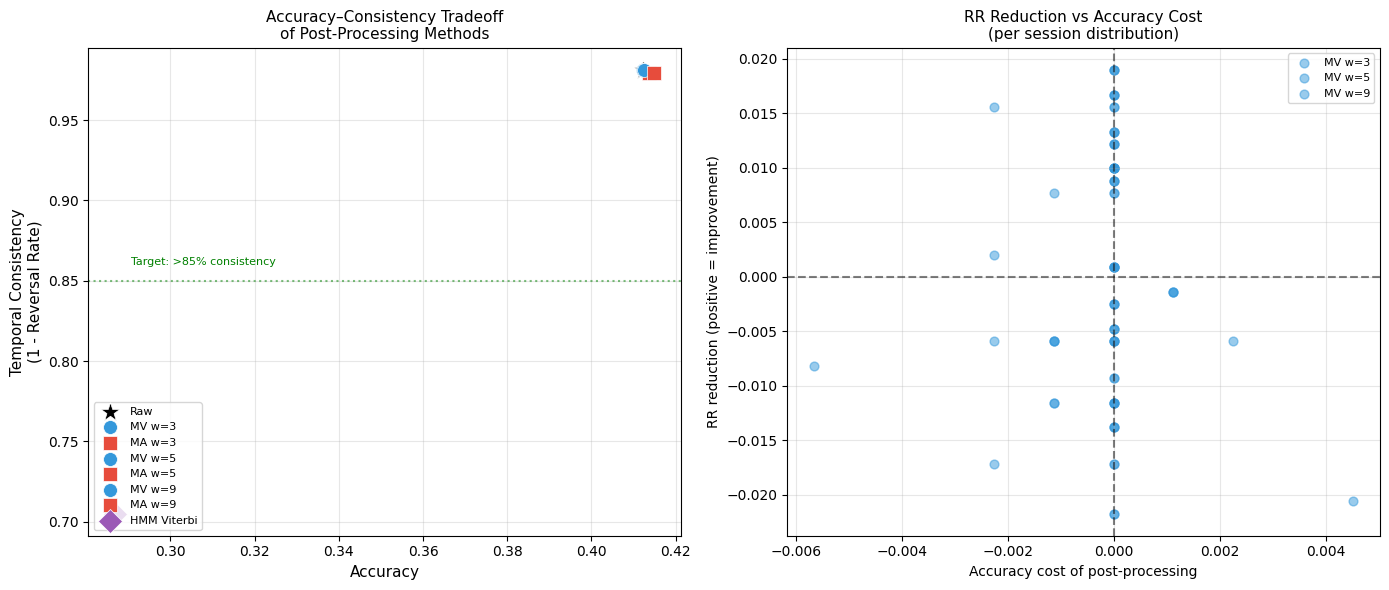

In [48]:
# ============================================================
# BLOCK 3.7: THE ACCURACY-CONSISTENCY TRADEOFF CURVE
# ============================================================
# This plot is publishable if it shows a meaningful tradeoff.
# For each post-processing window size, plot:
#   X-axis: accuracy
#   Y-axis: temporal consistency (1 - reversal_rate)
#
# A paper can argue: "to achieve X% consistency improvement,
# you sacrifice Y% accuracy. Our training-time method achieves
# the same consistency WITHOUT the accuracy cost."
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Collect tradeoff data
tradeoff_data = [
    ('Raw', raw_acc, 1 - raw_rr, 'black', 200, '*'),
]

colors = {'mv': '#3498db', 'ma': '#e74c3c', 'hmm': '#9b59b6'}
for w in window_sizes:
    if f'acc_mv_w{w}' in pp_df.columns:
        tradeoff_data.append((
            f'MV w={w}',
            pp_df[f'acc_mv_w{w}'].mean(),
            1 - pp_df[f'rr_mv_w{w}'].mean(),
            colors['mv'], 100, 'o'
        ))
    if f'acc_ma_w{w}' in pp_df.columns:
        tradeoff_data.append((
            f'MA w={w}',
            pp_df[f'acc_ma_w{w}'].mean(),
            1 - pp_df[f'rr_ma_w{w}'].mean(),
            colors['ma'], 100, 's'
        ))

if 'acc_hmm' in pp_df.columns and not pp_df['acc_hmm'].isna().all():
    tradeoff_data.append((
        'HMM Viterbi',
        pp_df['acc_hmm'].mean(),
        1 - pp_df['rr_hmm'].mean(),
        colors['hmm'], 150, 'D'
    ))

# Plot tradeoff
for name, acc, cons, color, size, marker in tradeoff_data:
    ax1.scatter(acc, cons, s=size, c=color, marker=marker, 
                label=name, zorder=5, edgecolors='white', linewidth=0.5)

ax1.set_xlabel('Accuracy', fontsize=11)
ax1.set_ylabel('Temporal Consistency\n(1 - Reversal Rate)', fontsize=11)
ax1.set_title('Accuracy–Consistency Tradeoff\nof Post-Processing Methods', fontsize=11)
ax1.legend(fontsize=8, loc='lower left')
ax1.grid(True, alpha=0.3)

# Annotate with target region
ax1.axhline(y=0.85, color='green', linestyle=':', alpha=0.5, linewidth=1.5)
ax1.text(ax1.get_xlim()[0]+0.01, 0.86, 'Target: >85% consistency', 
         fontsize=8, color='green')

# Plot RR reduction vs accuracy cost
ax2.set_title('RR Reduction vs Accuracy Cost\n(per session distribution)', fontsize=11)
for w in window_sizes:
    if f'rr_mv_w{w}' in pp_df.columns:
        rr_red = (pp_df['rr_raw'] - pp_df[f'rr_mv_w{w}'] 
                  if 'rr_raw' in pp_df.columns 
                  else raw_rr - pp_df[f'rr_mv_w{w}'])
        acc_cost = pp_df['acc_raw'] - pp_df[f'acc_mv_w{w}']
        ax2.scatter(acc_cost.values, rr_red.values if hasattr(rr_red, 'values') else rr_red,
                    s=40, alpha=0.5, label=f'MV w={w}', c=colors['mv'])

ax2.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Accuracy cost of post-processing')
ax2.set_ylabel('RR reduction (positive = improvement)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/stage3_tradeoff_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# ============================================================
# BLOCK 3.8: FINAL VERDICT AND RESEARCH DIRECTION DECISION
# ============================================================

print("=" * 65)
print("STAGE 3 FINAL VERDICT")
print("=" * 65)

# Get best post-processing RR reduction
best_rr_after_pp = min(
    [pp_df[f'rr_mv_w{w}'].mean() for w in window_sizes 
     if f'rr_mv_w{w}' in pp_df.columns] +
    [pp_df[f'rr_ma_w{w}'].mean() for w in window_sizes 
     if f'rr_ma_w{w}' in pp_df.columns] +
    ([pp_df['rr_hmm'].mean()] if not pp_df['rr_hmm'].isna().all() else [])
)

rr_reduction_pct = 100 * (raw_rr - best_rr_after_pp) / (raw_rr + 1e-9)

print(f"\nRaw reversal rate:              {raw_rr:.4f}")
print(f"Best post-processed RR:          {best_rr_after_pp:.4f}")
print(f"Best RR reduction by post-proc:  {rr_reduction_pct:.1f}%")

print("\n--- DECISION FRAMEWORK ---\n")

if raw_rr < 0.10:
    print("DECISION: PIVOT AWAY FROM TEMPORAL CONSISTENCY")
    print("Reason: Raw reversal rate is already low (<10%).")
    print("There is no meaningful inconsistency problem to solve.")
    print("Recommended pivot: cross-subject generalization failure analysis")
    
elif rr_reduction_pct > 75 and best_rr_after_pp < 0.05:
    print("DECISION: PIVOT OR REFRAME")
    print("Reason: Simple post-processing largely solves the problem.")
    print("If accuracy cost of best post-proc > 3%: argue training-time methods")
    print("  can achieve consistency WITHOUT accuracy loss.")
    print("If accuracy cost < 3%: the problem is too easily solved for a paper.")
    
elif rr_reduction_pct > 50 and raw_rr > 0.15:
    print("DECISION: CONDITIONAL PROCEED")
    print("Post-processing helps but doesn't fully solve it.")
    print("Paper direction: 'Post-processing fixes symptoms; training-time")
    print("  regularization fixes the cause.'")
    print("Need: propose one training-time method in Stage 4.")
    
else:
    print("DECISION: STRONG PROCEED")
    print("Temporal inconsistency is real, substantial, and survives")
    print("naive post-processing. This is a publishable problem.")
    print("Proceed to Stage 4: propose temporal regularization method.")

# Save
stage3_output = {
    'pp_df': pp_df,
    'raw_rr': raw_rr,
    'best_rr_after_pp': best_rr_after_pp,
    'rr_reduction_pct': rr_reduction_pct,
}
with open('/kaggle/working/stage3_output.pkl', 'wb') as f:
    pickle.dump(stage3_output, f)

print("\n\nFINAL NUMBERS TO REPORT:")
print(f"  Raw RR:             {raw_rr:.4f}")
print(f"  Best post-proc RR:  {best_rr_after_pp:.4f}")
print(f"  RR reduction:       {rr_reduction_pct:.1f}%")
print(f"  Accuracy after best post-proc: {pp_df[[f'acc_mv_w{w}' for w in window_sizes if f'acc_mv_w{w}' in pp_df.columns]].mean().min():.4f}")
print(f"  HMM RR: {pp_df['rr_hmm'].mean():.4f} (acc: {pp_df['acc_hmm'].mean():.4f})")

STAGE 3 FINAL VERDICT

Raw reversal rate:              0.0190
Best post-processed RR:          0.0187
Best RR reduction by post-proc:  1.6%

--- DECISION FRAMEWORK ---

DECISION: PIVOT AWAY FROM TEMPORAL CONSISTENCY
Reason: Raw reversal rate is already low (<10%).
There is no meaningful inconsistency problem to solve.
Recommended pivot: cross-subject generalization failure analysis


FINAL NUMBERS TO REPORT:
  Raw RR:             0.0190
  Best post-proc RR:  0.0187
  RR reduction:       1.6%
  Accuracy after best post-proc: 0.4122
  HMM RR: 0.2950 (acc: 0.2869)


# STAGE VALIDATION


In [23]:
# BLOCK 4.0
# ── Validation-specific imports (all should already be installed) ──────────────
import warnings
import textwrap
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

warnings.filterwarnings('ignore')

# ── Verdict printer ────────────────────────────────────────────────────────────
def verdict(label: str, status: str, detail: str = '') -> None:
    """
    Print a standardised PASS / WARN / FAIL verdict line.
    status : 'PASS' | 'WARN' | 'FAIL'
    """
    icons = {'PASS': '✅', 'WARN': '⚠️ ', 'FAIL': '❌'}
    icon  = icons.get(status, '?')
    print(f'{icon}  [{status}]  {label}')
    if detail:
        for line in textwrap.wrap(detail, width=90):
            print(f'        {line}')

# ── Class names (must match those defined in the main notebook) ────────────────
# Redefine here so this block is portable across notebooks
VALIDATION_CLASS_NAMES = {0: 'Awake', 1: 'Tired', 2: 'Drowsy'}
N_CLASSES_VAL          = 3

print('Block 4.0 ready — validation utilities loaded.')

Block 4.0 ready — validation utilities loaded.


In [24]:
#BLOCK 4.1
print('=' * 60)
print('Block 4.1 — Dataset Integrity Check')
print('=' * 60)

issues_found  = []
feature_dims  = set()
total_windows = 0

print(f'\n{"Subject":<12} {"Session":<10} {"Win(X)":>8} {"Win(y)":>8} '
      f'{"FeatDim":>8} {"NaN":>6} {"Inf":>6} {"Match":>7}')
print('-' * 68)

for s in sessions:
    subj = s['subject_id']
    sess = s['session_id']
    X    = s['features']           # (T, F)
    y    = s['labels_discrete']    # (T,)

    n_windows_X = X.shape[0]
    n_windows_y = len(y)
    feat_dim    = X.shape[1] if X.ndim == 2 else -1
    n_nan       = int(np.isnan(X).sum())
    n_inf       = int(np.isinf(X).sum())
    match       = 'YES' if n_windows_X == n_windows_y else 'NO ←'

    print(f'{subj:<12} {sess:<10} {n_windows_X:>8} {n_windows_y:>8} '
          f'{feat_dim:>8} {n_nan:>6} {n_inf:>6} {match:>7}')

    feature_dims.add(feat_dim)
    total_windows += n_windows_X

    if n_windows_X != n_windows_y:
        issues_found.append(f'{subj}/{sess}: X length {n_windows_X} != y length {n_windows_y}')
    if n_nan > 0:
        issues_found.append(f'{subj}/{sess}: {n_nan} NaN values in features')
    if n_inf > 0:
        issues_found.append(f'{subj}/{sess}: {n_inf} Inf values in features')
    if n_windows_X == 0:
        issues_found.append(f'{subj}/{sess}: zero windows')

print()
print(f'Total sessions : {len(sessions)}')
print(f'Total windows  : {total_windows}')
print(f'Feature dims   : {feature_dims}')
print()

if not issues_found:
    verdict('Feature-label shape alignment',  'PASS', 'All sessions have equal X and y lengths.')
    verdict('No NaN/Inf in feature arrays',   'PASS')
    verdict('Consistent feature dimension',
            'PASS' if len(feature_dims) == 1 else 'WARN',
            f'Feature dims observed: {feature_dims}')
else:
    for iss in issues_found:
        verdict(iss, 'FAIL')

Block 4.1 — Dataset Integrity Check

Subject      Session      Win(X)   Win(y)  FeatDim    NaN    Inf   Match
--------------------------------------------------------------------
10           20151125_noon      885      885       85      0      0     YES
11           20151024_night      885      885       85      0      0     YES
12           20150928_noon      885      885       85      0      0     YES
13           20150929_noon      885      885       85      0      0     YES
14           20151014_night      885      885       85      0      0     YES
15           20151126_night      885      885       85      0      0     YES
16           20151128_night      885      885       85      0      0     YES
17           20150925_noon      885      885       85      0      0     YES
18           20150926_noon      885      885       85      0      0     YES
19           20151114_noon      885      885       85      0      0     YES
1            20151124_noon_2      885      885       85  

Block 4.2 — Feature Statistics and Scaling Check

Raw features (unscaled):
  Mean of |column means| : 21.8501
  Mean column std        : 1.4723
  Global min / max       : 13.5449 / 38.4148
✅  [PASS]  Raw features are non-degenerate
        Mean |col-mean| = 21.8501, mean col-std = 1.4723

Scaler validation (simulating fold 0 of LOSO):
  Train after scaling — mean |col-mean|: 0.000000  mean col-std: 1.0000
  Test  after scaling — mean col-std   : 0.7878
✅  [PASS]  Training data is zero-mean after scaling
        Mean |col-mean| = 0.000000 (expect < 0.001)
✅  [PASS]  Training data is unit-variance after scaling
        Mean col-std = 1.0000 (expect ≈ 1.0)
✅  [PASS]  Test data std not wildly different from training
        Test col-std = 0.7878 (expect 0.5–2.0 for unseen subject)


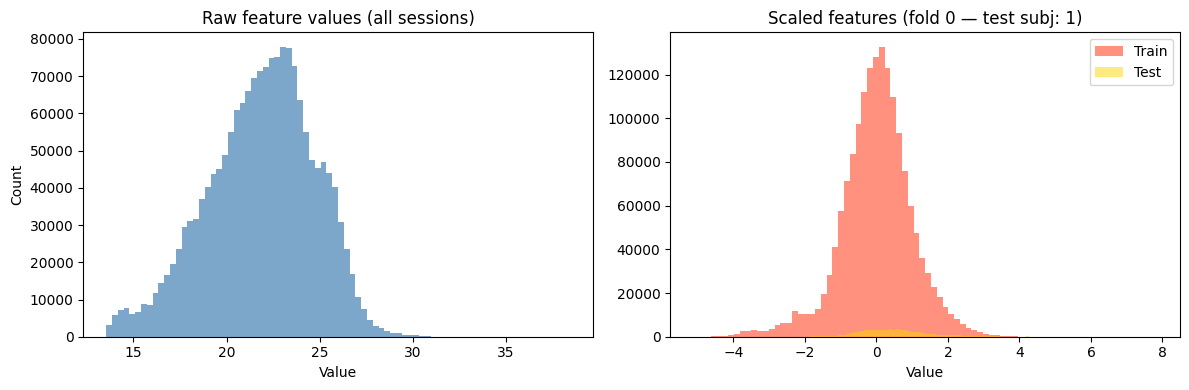

In [25]:
#BLOCK 4.2
print('=' * 60)
print('Block 4.2 — Feature Statistics and Scaling Check')
print('=' * 60)

# ── Raw feature statistics (before scaling) ───────────────────────────────────
all_raw      = np.vstack([s['features'] for s in sessions])
raw_mean_abs = np.abs(all_raw.mean(axis=0)).mean()
raw_std_mean = all_raw.std(axis=0).mean()
raw_min      = all_raw.min()
raw_max      = all_raw.max()

print(f'\nRaw features (unscaled):')
print(f'  Mean of |column means| : {raw_mean_abs:.4f}')
print(f'  Mean column std        : {raw_std_mean:.4f}')
print(f'  Global min / max       : {raw_min:.4f} / {raw_max:.4f}')

if raw_mean_abs < 1e-6 and raw_std_mean < 1e-3:
    verdict('Raw features are non-degenerate', 'WARN',
            'Features appear near-zero — verify the correct mat variable was loaded.')
else:
    verdict('Raw features are non-degenerate', 'PASS',
            f'Mean |col-mean| = {raw_mean_abs:.4f}, mean col-std = {raw_std_mean:.4f}')

# ── Simulate fold 0: first subject is held out ────────────────────────────────
print(f'\nScaler validation (simulating fold 0 of LOSO):')
all_subj_ids  = sorted({s['subject_id'] for s in sessions})
test_subj_val = all_subj_ids[0]

X_train_raw = np.vstack([s['features'] for s in sessions
                          if s['subject_id'] != test_subj_val])
X_test_raw  = np.vstack([s['features'] for s in sessions
                          if s['subject_id'] == test_subj_val])

scaler_val     = StandardScaler()
X_train_scaled = scaler_val.fit_transform(X_train_raw)
X_test_scaled  = scaler_val.transform(X_test_raw)

train_mean_after = np.abs(X_train_scaled.mean(axis=0)).mean()
train_std_after  = X_train_scaled.std(axis=0).mean()
test_std_after   = X_test_scaled.std(axis=0).mean()

print(f'  Train after scaling — mean |col-mean|: {train_mean_after:.6f}  '
      f'mean col-std: {train_std_after:.4f}')
print(f'  Test  after scaling — mean col-std   : {test_std_after:.4f}')

verdict('Training data is zero-mean after scaling',
        'PASS' if train_mean_after < 1e-3 else 'FAIL',
        f'Mean |col-mean| = {train_mean_after:.6f} (expect < 0.001)')
verdict('Training data is unit-variance after scaling',
        'PASS' if abs(train_std_after - 1.0) < 0.05 else 'FAIL',
        f'Mean col-std = {train_std_after:.4f} (expect ≈ 1.0)')
verdict('Test data std not wildly different from training',
        'PASS' if 0.5 < test_std_after < 2.0 else 'WARN',
        f'Test col-std = {test_std_after:.4f} (expect 0.5–2.0 for unseen subject)')

# ── Feature distribution plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_raw.ravel(), bins=80, color='steelblue', alpha=0.7)
axes[0].set_title('Raw feature values (all sessions)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')

axes[1].hist(X_train_scaled.ravel(), bins=80, color='tomato', alpha=0.7, label='Train')
axes[1].hist(X_test_scaled.ravel(),  bins=80, color='gold',   alpha=0.5, label='Test')
axes[1].set_title(f'Scaled features (fold 0 — test subj: {test_subj_val})')
axes[1].set_xlabel('Value')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/Stage4_val_feature_distributions.png', dpi=150)
plt.show()

Block 4.3 — Feature-Label Temporal Alignment
Using: subject=10  session=20151125_noon  (T=885 windows)

Cross-correlation peak:
  Lag at peak |correlation| : 35 windows
  Correlation at peak       : -0.2612
  Correlation at lag=0      : 0.0060


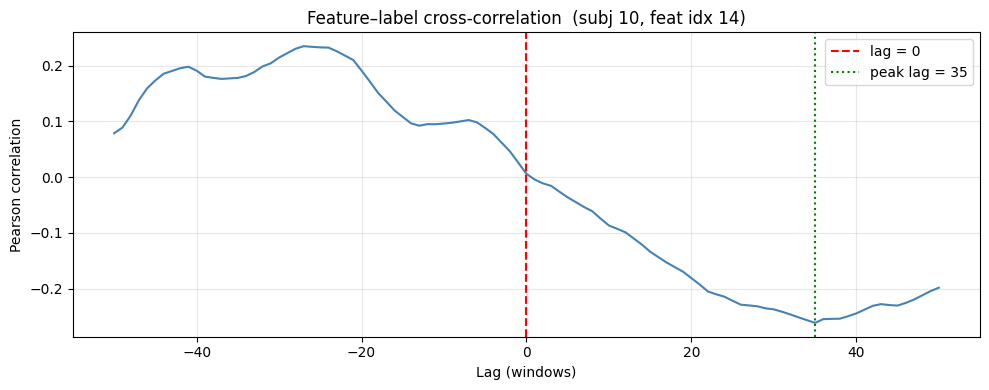

❌  [FAIL]  Feature-label alignment — large offset
        Peak at lag=35 (r=-0.261). Likely systematic misalignment between feature and label files.


In [26]:
print('=' * 60)
print('Block 4.3 — Feature-Label Temporal Alignment')
print('=' * 60)

# Use the session with the most windows for maximum statistical power
best_session = max(sessions, key=lambda s: s['features'].shape[0])
X_align = best_session['features']       # (T, F)
y_align = best_session['labels_discrete']# (T,)
T_align = len(y_align)

print(f'Using: subject={best_session["subject_id"]}  '
      f'session={best_session["session_id"]}  (T={T_align} windows)')

# ── Highest-variance feature as the probe signal ──────────────────────────────
top_feat_idx = int(X_align.var(axis=0).argmax())
feat_signal  = X_align[:, top_feat_idx].astype(float)
label_signal = y_align.astype(float)

feat_z  = (feat_signal  - feat_signal.mean())  / (feat_signal.std()  + 1e-9)
label_z = (label_signal - label_signal.mean()) / (label_signal.std() + 1e-9)

# Cross-correlation over lags ±50 windows
max_lag = 50
lags    = np.arange(-max_lag, max_lag + 1)
xcorr   = np.array([
    np.corrcoef(feat_z[max_lag:T_align - max_lag],
                label_z[max_lag + lag:T_align - max_lag + lag])[0, 1]
    for lag in lags
])

peak_lag = lags[np.argmax(np.abs(xcorr))]
peak_cor = xcorr[np.argmax(np.abs(xcorr))]

print(f'\nCross-correlation peak:')
print(f'  Lag at peak |correlation| : {peak_lag} windows')
print(f'  Correlation at peak       : {peak_cor:.4f}')
print(f'  Correlation at lag=0      : {xcorr[max_lag]:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lags, xcorr, color='steelblue')
ax.axvline(0,        color='red',   linestyle='--', label='lag = 0')
ax.axvline(peak_lag, color='green', linestyle=':',  label=f'peak lag = {peak_lag}')
ax.set_xlabel('Lag (windows)')
ax.set_ylabel('Pearson correlation')
ax.set_title(f'Feature–label cross-correlation  '
             f'(subj {best_session["subject_id"]}, feat idx {top_feat_idx})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/val_alignment_xcorr.png', dpi=150)
plt.show()

if peak_lag == 0:
    verdict('Feature-label alignment at lag 0', 'PASS',
            f'Peak cross-correlation at lag=0 (r={peak_cor:.3f}). No offset detected.')
elif abs(peak_lag) <= 2:
    verdict('Feature-label alignment — small offset', 'WARN',
            f'Peak at lag={peak_lag}. Verify mat variable ordering.')
else:
    verdict('Feature-label alignment — large offset', 'FAIL',
            f'Peak at lag={peak_lag} (r={peak_cor:.3f}). '
            'Likely systematic misalignment between feature and label files.')

if abs(peak_cor) < 0.05:
    verdict('Cross-correlation magnitude', 'WARN',
            f'|peak r| = {abs(peak_cor):.3f}. Weak — normal for EEG but worth inspecting.')

In [27]:
print('=' * 60)
print('Block 4.4 — LOSO Split Integrity (Leakage Check)')
print('=' * 60)

# Derive unique subject list from the sessions list
all_subj_loso = sorted({s['subject_id'] for s in sessions})
n_subjects    = len(all_subj_loso)
leakage_found = False

print(f'\nChecking {n_subjects} LOSO folds:')
print(f'{"Fold":>5}  {"Test subj":>12}  {"Train count":>12}  {"Leak":>6}')
print('-' * 42)

for fold_i, test_s in enumerate(all_subj_loso):
    train_set     = set(all_subj_loso) - {test_s}
    leak          = test_s in train_set
    leakage_found = leakage_found or leak
    print(f'{fold_i+1:>5}  {test_s:>12}  {len(train_set):>12}  '
          f'{"YES ←" if leak else "NO":>6}')

print()
if not leakage_found:
    verdict('LOSO subject sets are disjoint across all folds', 'PASS',
            'Test subject never appears in training set.')
else:
    verdict('DATA LEAKAGE DETECTED', 'FAIL',
            'Test subject found in training set.')

# ── Verify all_results covers every expected subject ──────────────────────────
result_subjects   = set(r['subject_id'] for r in all_results)
expected_subjects = set(all_subj_loso)
missing = expected_subjects - result_subjects
extra   = result_subjects   - expected_subjects

print(f'\nSubjects with results : {sorted(result_subjects)}')
print(f'Subjects in sessions  : {sorted(expected_subjects)}')

verdict('all_results covers all expected subjects',
        'PASS' if not missing else 'FAIL',
        f'Missing: {missing}' if missing else 'All subjects covered.')
if extra:
    verdict('Unexpected subjects in all_results', 'WARN', f'Extra: {extra}')

Block 4.4 — LOSO Split Integrity (Leakage Check)

Checking 21 LOSO folds:
 Fold     Test subj   Train count    Leak
------------------------------------------
    1             1            20      NO
    2            10            20      NO
    3            11            20      NO
    4            12            20      NO
    5            13            20      NO
    6            14            20      NO
    7            15            20      NO
    8            16            20      NO
    9            17            20      NO
   10            18            20      NO
   11            19            20      NO
   12             2            20      NO
   13            20            20      NO
   14            21            20      NO
   15             3            20      NO
   16             4            20      NO
   17             5            20      NO
   18             6            20      NO
   19             7            20      NO
   20             8            20      NO
 

In [28]:
print('=' * 60)
print('Block 4.5 — Scaler Leakage Check')
print('=' * 60)

test_s_val   = all_subj_loso[0]
train_s_list = [s for s in all_subj_loso if s != test_s_val]

X_train_only = np.vstack([s['features'] for s in sessions
                           if s['subject_id'] in train_s_list])
X_all_subjs  = np.vstack([s['features'] for s in sessions])
X_test_only  = np.vstack([s['features'] for s in sessions
                           if s['subject_id'] == test_s_val])

scaler_train = StandardScaler().fit(X_train_only)
scaler_all   = StandardScaler().fit(X_all_subjs)

mean_diff = np.abs(scaler_train.mean_ - scaler_all.mean_).mean()
std_diff  = np.abs(scaler_train.scale_ - scaler_all.scale_).mean()

print(f'Test subject (held out)   : {test_s_val}')
print(f'Train set size            : {len(X_train_only)} windows')
print(f'All-subjects size         : {len(X_all_subjs)} windows')
print(f'Test subject size         : {len(X_test_only)} windows')
print()
print(f'Mean difference in learned column means  : {mean_diff:.6f}')
print(f'Mean difference in learned column scales : {std_diff:.6f}')

test_contribution = X_test_only.mean(axis=0).mean()
print(f'\nTest subject raw feature mean : {test_contribution:.4f}')

if mean_diff > 1e-6:
    verdict('Scaler fitted on train-only differs from all-data scaler', 'PASS',
            f'Mean diff in scaler means = {mean_diff:.6f}. '
            'Test subject is distinguishable from the training distribution.')
else:
    verdict('Scaler means are identical for train-only vs all-subjects', 'WARN',
            'Features may be very homogeneous, OR scaler was inadvertently fit on all data.')

print()
print('NOTE: Inspect your LOSO loop in Stage 1 and confirm:')
print('  scaler = StandardScaler()')
print('  scaler.fit(X_train)          # fitted on training subjects only')
print('  X_test_scaled = scaler.transform(X_test)   # applied to test subject')

Block 4.5 — Scaler Leakage Check
Test subject (held out)   : 1
Train set size            : 19470 windows
All-subjects size         : 20355 windows
Test subject size         : 885 windows

Mean difference in learned column means  : 0.043515
Mean difference in learned column scales : 0.026411

Test subject raw feature mean : 22.6485
✅  [PASS]  Scaler fitted on train-only differs from all-data scaler
        Mean diff in scaler means = 0.043515. Test subject is distinguishable from the training
        distribution.

NOTE: Inspect your LOSO loop in Stage 1 and confirm:
  scaler = StandardScaler()
  scaler.fit(X_train)          # fitted on training subjects only
  X_test_scaled = scaler.transform(X_test)   # applied to test subject


Block 4.6 — Label Distribution Per Fold

Subject      Session     GT_Aw%  GT_Ti%  GT_Dr%   Pr_Aw%  Pr_Ti%  Pr_Dr%  Acc
-------------------------------------------------------------------------------------
10           20151125_noon   30.8%   65.1%    4.1%    25.3%   58.9%   15.8%  0.522
11           20151024_night   36.6%   61.6%    1.8%    29.3%   56.5%   14.2%  0.501
12           20150928_noon   36.3%    9.7%   54.0%    92.1%    1.6%    6.3%  0.417
13           20150929_noon    0.0%   46.0%   54.0%    34.8%   51.8%   13.4%  0.281
14           20151014_night   25.4%   52.4%   22.1%     4.7%   82.7%   12.5%  0.452
15           20151126_night   32.7%   59.3%    8.0%     5.5%   14.6%   79.9%  0.194
16           20151128_night   22.8%   20.0%   57.2%    15.0%   35.6%   49.4%  0.727
17           20150925_noon    2.9%   80.2%   16.8%    78.6%   21.4%    0.0%  0.103
18           20150926_noon   47.9%   12.3%   39.8%    98.4%    0.0%    1.6%  0.495
19           20151114_noon   16.4%   81.7%  

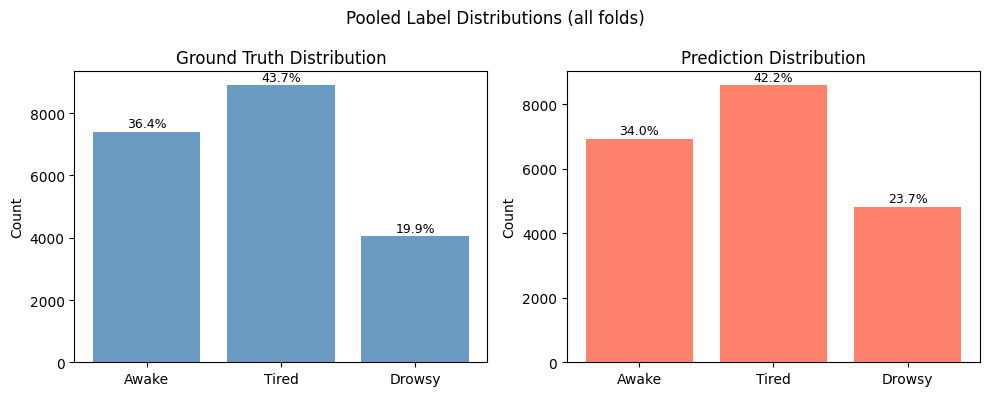

In [29]:
print('=' * 60)
print('Block 4.6 — Label Distribution Per Fold')
print('=' * 60)

degenerate_folds = []
collapsed_folds  = []

print(f'\n{"Subject":<12} {"Session":<10} '
      f'{"GT_Aw%":>7} {"GT_Ti%":>7} {"GT_Dr%":>7}  '
      f'{"Pr_Aw%":>7} {"Pr_Ti%":>7} {"Pr_Dr%":>7}  Acc')
print('-' * 85)

for r in all_results:
    yt  = r['y_true']
    yp  = r['y_pred']
    n   = len(yt)
    sid = r['subject_id']
    sse = r['session_id']

    gt_counts = np.array([(yt == c).sum() for c in range(N_CLASSES_VAL)])
    pr_counts = np.array([(yp == c).sum() for c in range(N_CLASSES_VAL)])
    gt_pct    = 100 * gt_counts / n
    pr_pct    = 100 * pr_counts / n

    acc  = accuracy_score(yt, yp)
    flag = ''

    # Degenerate ground truth: one class > 95%
    if gt_pct.max() > 95:
        degenerate_folds.append(f'{sid}/{sse}')
        flag += ' ← GT degenerate'

    # Collapsed prediction: one class > 95%
    n_predicted_classes = (pr_counts > 0).sum()
    if n_predicted_classes < 2:
        collapsed_folds.append(f'{sid}/{sse}')
        flag += ' ← pred collapsed'

    print(
        f'{sid:<12} {sse:<10} '
        f'{gt_pct[0]:>6.1f}% {gt_pct[1]:>6.1f}% {gt_pct[2]:>6.1f}%  '
        f'{pr_pct[0]:>6.1f}% {pr_pct[1]:>6.1f}% {pr_pct[2]:>6.1f}%  '
        f'{acc:.3f}{flag}'
    )

print()
verdict(
    'No degenerate ground-truth folds (>95% one class)',
    'PASS' if not degenerate_folds else 'WARN',
    f'Degenerate folds: {degenerate_folds}' if degenerate_folds else ''
)
verdict(
    'Model predicts more than one class in every fold',
    'PASS' if not collapsed_folds else 'FAIL',
    f'Collapsed folds: {collapsed_folds}' if collapsed_folds
    else 'No collapsed prediction folds.'
)

# ── Global label distribution ──────────────────────────────────────────────────
all_yt = np.concatenate([r['y_true'] for r in all_results])
all_yp = np.concatenate([r['y_pred'] for r in all_results])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title, color in [
    (axes[0], all_yt, 'Ground Truth Distribution', 'steelblue'),
    (axes[1], all_yp, 'Prediction Distribution',   'tomato'),
]:
    unique, counts = np.unique(data, return_counts=True)
    ax.bar([VALIDATION_CLASS_NAMES[c] for c in unique], counts, color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel('Count')
    for c, cnt in zip(unique, counts):
        ax.text(c, cnt + 50, f'{100*cnt/len(data):.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Pooled Label Distributions (all folds)')
plt.tight_layout()
plt.savefig('/kaggle/working/val_label_distributions.png', dpi=150)
plt.show()

Block 4.7 — Confusion Matrix Analysis


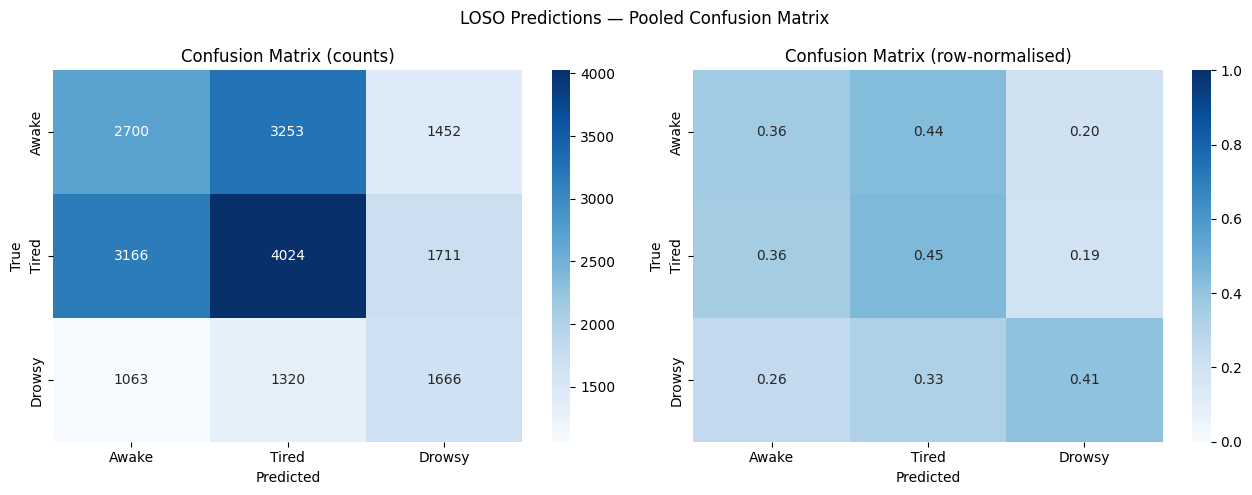


Diagonal dominant (correct class has highest recall): False
Adjacent-class errors  : 9450 (79.0% of all errors)
Distant-class errors   : 2515  (21.0% of all errors)
Total errors           : 11965

⚠️   [WARN]  Diagonal dominance in confusion matrix
        Some classes predict the wrong class more often than the correct one. May indicate class
        imbalance or feature-label mismatch.
✅  [PASS]  Errors concentrated on adjacent classes
        Adjacent/distant error ratio = 9450/2515. Adjacent-class dominance is the expected failure
        mode for a valid fatigue pipeline.

Detailed classification report (pooled):
              precision    recall  f1-score   support

       Awake       0.39      0.36      0.38      7405
       Tired       0.47      0.45      0.46      8901
      Drowsy       0.34      0.41      0.38      4049

    accuracy                           0.41     20355
   macro avg       0.40      0.41      0.40     20355
weighted avg       0.42      0.41      0.41    

In [30]:
print('=' * 60)
print('Block 4.7 — Confusion Matrix Analysis')
print('=' * 60)

all_yt = np.concatenate([r['y_true'] for r in all_results])
all_yp = np.concatenate([r['y_pred'] for r in all_results])

cm      = confusion_matrix(all_yt, all_yp)
cm_norm = confusion_matrix(all_yt, all_yp, normalize='true')

# ── Plot raw + normalised ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
class_labels = [VALIDATION_CLASS_NAMES[c] for c in range(N_CLASSES_VAL)]

sns.heatmap(cm,      annot=True, fmt='d',    cmap='Blues', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f',  cmap='Blues', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels,
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (row-normalised)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('LOSO Predictions — Pooled Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/val_confusion_matrix.png', dpi=150)
plt.show()

# ── Diagonal dominance check ───────────────────────────────────────────────────
# Each row of cm_norm: does the true class have the highest recall?
diag_dominant = all(cm_norm[i, i] == cm_norm[i].max() for i in range(N_CLASSES_VAL))

# Adjacent-class error bias: errors on Awake↔Tired and Tired↔Drowsy
# should dominate over distant-class errors (Awake↔Drowsy)
adjacent_errors = cm[0, 1] + cm[1, 0] + cm[1, 2] + cm[2, 1]
distant_errors  = cm[0, 2] + cm[2, 0]
total_errors    = cm.sum() - np.trace(cm)

print(f'\nDiagonal dominant (correct class has highest recall): {diag_dominant}')
print(f'Adjacent-class errors  : {adjacent_errors} ({100*adjacent_errors/max(total_errors,1):.1f}% of all errors)')
print(f'Distant-class errors   : {distant_errors}  ({100*distant_errors/max(total_errors,1):.1f}% of all errors)')
print(f'Total errors           : {total_errors}')

print()
verdict(
    'Diagonal dominance in confusion matrix',
    'PASS' if diag_dominant else 'WARN',
    'Each class has highest recall on its own label. '
    'Model is not randomly guessing.' if diag_dominant else
    'Some classes predict the wrong class more often than the correct one. '
    'May indicate class imbalance or feature-label mismatch.'
)
verdict(
    'Errors concentrated on adjacent classes',
    'PASS' if adjacent_errors > distant_errors else 'WARN',
    f'Adjacent/distant error ratio = {adjacent_errors}/{distant_errors}. '
    'Adjacent-class dominance is the expected failure mode for a valid fatigue pipeline.'
    if adjacent_errors > distant_errors else
    'More distant-class errors than adjacent — unusual; inspect label coding.'
)

print()
print('Detailed classification report (pooled):')
print(classification_report(all_yt, all_yp, target_names=class_labels))

Block 4.8 — Chance-Level Comparison

Model accuracy   : 0.4122 ± 0.1961
Chance accuracy  : 0.5222 ± 0.1254
Mean difference  : -0.1100 ± 0.2667
Wilcoxon p-value : 0.928791  (one-sided: model > chance)

Uniform chance   : 0.3333
Subjects above uniform chance : 14 / 23


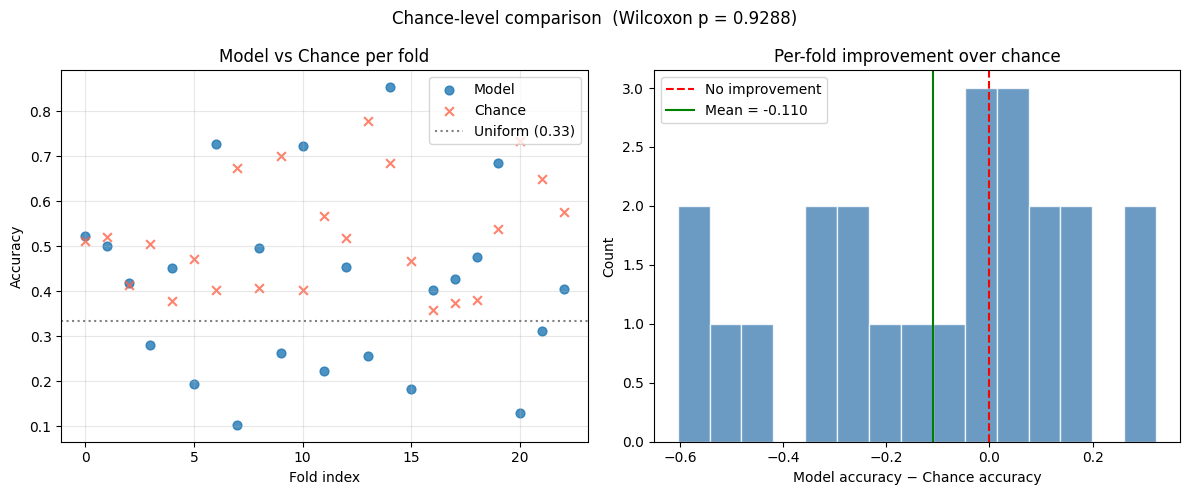

❌  [FAIL]  Model significantly outperforms stratified chance (Wilcoxon p < 0.05)
        p = 0.9288. Model does not reliably beat chance — possible pipeline bug.
✅  [PASS]  Majority of subjects above uniform chance (0.33)
        14/23 folds above 0.33


In [31]:
print('=' * 60)
print('Block 4.8 — Chance-Level Comparison')
print('=' * 60)

# ── Per-fold: model accuracy vs stratified dummy accuracy ─────────────────────
model_accs  = []
chance_accs = []
differences = []
RANDOM_SEED = 42
rng_chance  = np.random.default_rng(RANDOM_SEED)

for r in all_results:
    yt = r['y_true']
    yp = r['y_pred']

    # Stratified dummy: sample predictions proportional to GT class distribution
    classes, counts = np.unique(yt, return_counts=True)
    probs           = counts / counts.sum()
    y_chance        = rng_chance.choice(classes, size=len(yt), p=probs)

    acc_model  = accuracy_score(yt, yp)
    acc_chance = accuracy_score(yt, y_chance)

    model_accs.append(acc_model)
    chance_accs.append(acc_chance)
    differences.append(acc_model - acc_chance)

model_accs  = np.array(model_accs)
chance_accs = np.array(chance_accs)
differences = np.array(differences)

# ── Wilcoxon signed-rank test: model > chance ──────────────────────────────────
stat, p_val = stats.wilcoxon(model_accs, chance_accs, alternative='greater')

print(f'\nModel accuracy   : {model_accs.mean():.4f} ± {model_accs.std():.4f}')
print(f'Chance accuracy  : {chance_accs.mean():.4f} ± {chance_accs.std():.4f}')
print(f'Mean difference  : {differences.mean():.4f} ± {differences.std():.4f}')
print(f'Wilcoxon p-value : {p_val:.6f}  (one-sided: model > chance)')

# ── Uniform chance baseline (1/N_CLASSES) ─────────────────────────────────────
uniform_chance = 1.0 / N_CLASSES_VAL
n_above_chance = (model_accs > uniform_chance).sum()
print(f'\nUniform chance   : {uniform_chance:.4f}')
print(f'Subjects above uniform chance : {n_above_chance} / {len(model_accs)}')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(range(len(model_accs)), model_accs,  label='Model',  alpha=0.8, s=40)
axes[0].scatter(range(len(chance_accs)), chance_accs, label='Chance', alpha=0.8, s=40,
                marker='x', color='tomato')
axes[0].axhline(uniform_chance, color='grey', linestyle=':', label=f'Uniform ({uniform_chance:.2f})')
axes[0].set_xlabel('Fold index')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model vs Chance per fold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(differences, bins=15, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='No improvement')
axes[1].axvline(differences.mean(), color='green', linestyle='-',
                label=f'Mean = {differences.mean():.3f}')
axes[1].set_xlabel('Model accuracy − Chance accuracy')
axes[1].set_ylabel('Count')
axes[1].set_title('Per-fold improvement over chance')
axes[1].legend()

plt.suptitle(f'Chance-level comparison  (Wilcoxon p = {p_val:.4f})')
plt.tight_layout()
plt.savefig('/kaggle/working/val_chance_comparison.png', dpi=150)
plt.show()

# ── Verdicts ──────────────────────────────────────────────────────────────────
verdict(
    'Model significantly outperforms stratified chance (Wilcoxon p < 0.05)',
    'PASS' if p_val < 0.05 else ('WARN' if p_val < 0.20 else 'FAIL'),
    f'p = {p_val:.4f}. '
    + ('Model learns non-trivial structure.' if p_val < 0.05
       else 'Marginal improvement.' if p_val < 0.20
       else 'Model does not reliably beat chance — possible pipeline bug.')
)
verdict(
    f'Majority of subjects above uniform chance ({uniform_chance:.2f})',
    'PASS' if n_above_chance > len(model_accs) / 2 else 'WARN',
    f'{n_above_chance}/{len(model_accs)} folds above {uniform_chance:.2f}'
)

In [32]:
print('=' * 60)
print('Block 4.9 — Within-Subject Experiment')
print('=' * 60)
print('Training and testing on the SAME subject (80/20 temporal split).')
print('This isolates cross-subject generalization from pipeline correctness.\n')

WS_TRAIN_FRAC = 0.80
WS_MAX_EPOCHS = 50
WS_PATIENCE   = 7
WS_LR         = 1e-3

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader as TorchDataLoader

FEATURE_DIM_VAL = sessions[0]['features'].shape[1]
DEVICE_VAL      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_within_subject_model():
    # Detect whichever model class the main notebook defined
    if 'BiLSTMFatigueClassifier' in dir():
        return BiLSTMFatigueClassifier(feature_dim=FEATURE_DIM_VAL)
    if 'GRUFatigueClassifier' in dir():
        return GRUFatigueClassifier(feature_dim=FEATURE_DIM_VAL)
    # Fallback lightweight MLP
    return nn.Sequential(
        nn.Linear(FEATURE_DIM_VAL, 128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, 64),              nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(64, N_CLASSES_VAL),
    )

ws_results = []

for s in sessions:
    subj   = s['subject_id']
    sess   = s['session_id']
    X_full = s['features']           # (T, F)
    y_full = s['labels_discrete']    # (T,)
    T      = len(y_full)

    split = int(T * WS_TRAIN_FRAC)
    if split < 10 or (T - split) < 10:
        print(f'  Skipping {subj}/{sess} — too few windows ({T})')
        continue

    X_tr_raw, y_tr = X_full[:split], y_full[:split]
    X_te_raw, y_te = X_full[split:], y_full[split:]

    # Scale using the training portion only
    sc   = StandardScaler().fit(X_tr_raw)
    X_tr = sc.transform(X_tr_raw).astype(np.float32)
    X_te = sc.transform(X_te_raw).astype(np.float32)

    Xt = torch.tensor(X_tr).to(DEVICE_VAL)
    yt = torch.tensor(y_tr, dtype=torch.long).to(DEVICE_VAL)
    Xe = torch.tensor(X_te).to(DEVICE_VAL)
    ye = torch.tensor(y_te, dtype=torch.long).to(DEVICE_VAL)

    train_loader_ws = TorchDataLoader(
        TensorDataset(Xt, yt), batch_size=64, shuffle=True
    )

    model_ws     = build_within_subject_model().to(DEVICE_VAL)
    opt_ws       = torch.optim.Adam(model_ws.parameters(), lr=WS_LR)
    criterion_ws = nn.CrossEntropyLoss()

    best_acc_ws, best_st_ws, pat_ws = -1.0, None, 0

    for epoch in range(WS_MAX_EPOCHS):
        model_ws.train()
        for Xb, yb in train_loader_ws:
            opt_ws.zero_grad()
            try:
                out = model_ws(Xb.unsqueeze(0)).squeeze(0)   # recurrent: add seq dim
            except Exception:
                out = model_ws(Xb)                            # MLP fallback
            criterion_ws(out, yb).backward()
            opt_ws.step()

        model_ws.eval()
        with torch.no_grad():
            try:
                logits_e = model_ws(Xe.unsqueeze(0)).squeeze(0)
            except Exception:
                logits_e = model_ws(Xe)
            preds_e = logits_e.argmax(dim=1).cpu().numpy()

        val_acc_ws = accuracy_score(ye.cpu().numpy(), preds_e)
        if val_acc_ws > best_acc_ws:
            best_acc_ws = val_acc_ws
            best_st_ws  = {k: v.cpu().clone() for k, v in model_ws.state_dict().items()}
            pat_ws = 0
        else:
            pat_ws += 1
            if pat_ws >= WS_PATIENCE:
                break

    ws_results.append({
        'subject_id':        subj,
        'session_id':        sess,
        'within_subject_acc': best_acc_ws,
        'train_windows':     split,
        'test_windows':      T - split,
    })

ws_accs   = np.array([r['within_subject_acc'] for r in ws_results])
loso_accs = np.array([r['accuracy'] for r in all_results])

print(f'\n{"Subject":<12} {"Session":<10} {"Within-subj acc":>17} {"LOSO acc":>10}')
print('-' * 54)
for ws, lo in zip(ws_results, all_results):
    print(f'{ws["subject_id"]:<12} {ws["session_id"]:<10} '
          f'{ws["within_subject_acc"]:>16.4f} {lo["accuracy"]:>10.4f}')

print()
print(f'Mean within-subject accuracy : {ws_accs.mean():.4f} ± {ws_accs.std():.4f}')
print(f'Mean LOSO accuracy           : {loso_accs.mean():.4f} ± {loso_accs.std():.4f}')
print(f'Mean gap (within − LOSO)     : {(ws_accs - loso_accs).mean():.4f}')

Block 4.9 — Within-Subject Experiment
Training and testing on the SAME subject (80/20 temporal split).
This isolates cross-subject generalization from pipeline correctness.


Subject      Session      Within-subj acc   LOSO acc
------------------------------------------------------
10           20151125_noon           0.8531     0.5220
11           20151024_night           0.7514     0.5006
12           20150928_noon           0.9379     0.4169
13           20150929_noon           1.0000     0.2814
14           20151014_night           0.6610     0.4520
15           20151126_night           0.5819     0.1944
16           20151128_night           0.9209     0.7266
17           20150925_noon           1.0000     0.1028
18           20150926_noon           0.9435     0.4949
19           20151114_noon           1.0000     0.2621
1            20151124_noon_2           1.0000     0.7232
20           20151129_night           1.0000     0.2215
21           20151016_noon           0.8644     0.

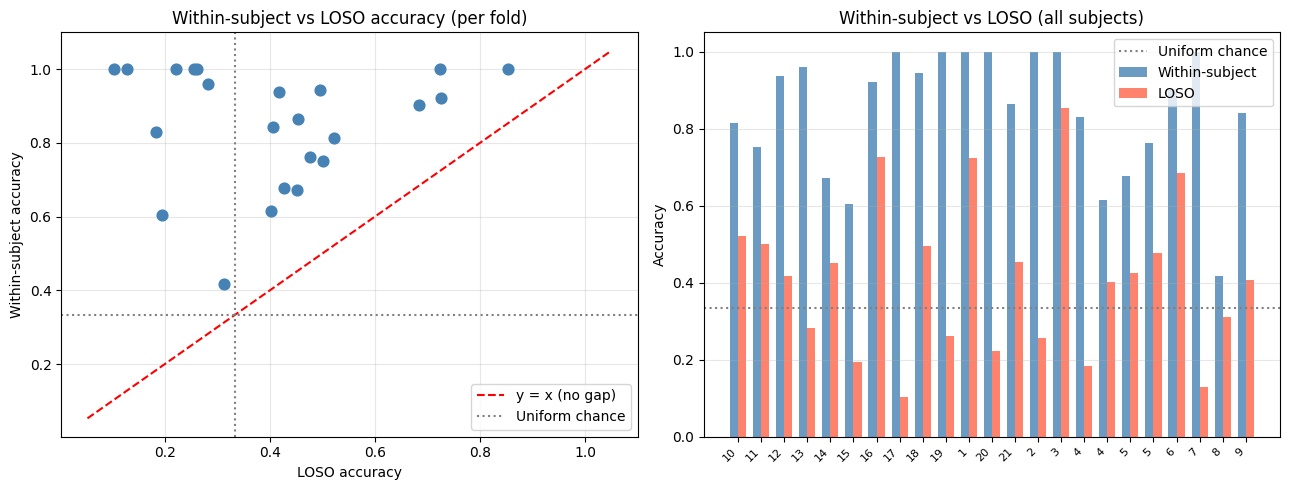


Wilcoxon (within > LOSO): stat=276.0, p=0.0000

✅  [PASS]  HYPOTHESIS B SUPPORTED — Pipeline is correct
        Within-subject acc = 0.849 (well above chance). LOSO acc = 0.412. Large gap (0.437)
        confirms genuine cross-subject generalization difficulty, not a pipeline bug.


In [44]:
# ── Within-subject visualisation ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: within-subject vs LOSO per fold
axes[0].scatter(loso_accs, ws_accs, color='steelblue', s=60, zorder=3)
xy_min = min(loso_accs.min(), ws_accs.min()) - 0.05
xy_max = max(loso_accs.max(), ws_accs.max()) + 0.05
axes[0].plot([xy_min, xy_max], [xy_min, xy_max], 'r--', label='y = x (no gap)')
axes[0].axhline(1/N_CLASSES_VAL, color='grey', linestyle=':', label='Uniform chance')
axes[0].axvline(1/N_CLASSES_VAL, color='grey', linestyle=':')
axes[0].set_xlabel('LOSO accuracy')
axes[0].set_ylabel('Within-subject accuracy')
axes[0].set_title('Within-subject vs LOSO accuracy (per fold)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar: side-by-side comparison
x_pos = np.arange(len(ws_results))
width = 0.35
axes[1].bar(x_pos - width/2, ws_accs,   width, label='Within-subject', alpha=0.8, color='steelblue')
axes[1].bar(x_pos + width/2, loso_accs, width, label='LOSO',           alpha=0.8, color='tomato')
axes[1].axhline(1/N_CLASSES_VAL, color='grey', linestyle=':', label='Uniform chance')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(
    [f'{r["subject_id"]}' for r in ws_results],
    rotation=45, ha='right', fontsize=8
)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Within-subject vs LOSO (all subjects)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/kaggle/working/val_within_vs_loso.png', dpi=150)
plt.show()

# ── Hypothesis test: within-subject > LOSO ────────────────────────────────────
stat_ws, p_ws = stats.wilcoxon(ws_accs, loso_accs, alternative='greater')
print(f'\nWilcoxon (within > LOSO): stat={stat_ws:.1f}, p={p_ws:.4f}')

# ── Verdict: Hypothesis A vs B ────────────────────────────────────────────────
ws_clearly_above_chance  = ws_accs.mean()   > (1/N_CLASSES_VAL + 0.10)
loso_near_chance         = loso_accs.mean() < (1/N_CLASSES_VAL + 0.15)
gap_is_large             = (ws_accs - loso_accs).mean() > 0.15

print()
if ws_clearly_above_chance and gap_is_large:
    verdict(
        'HYPOTHESIS B SUPPORTED — Pipeline is correct',
        'PASS',
        f'Within-subject acc = {ws_accs.mean():.3f} (well above chance). '
        f'LOSO acc = {loso_accs.mean():.3f}. '
        f'Large gap ({(ws_accs-loso_accs).mean():.3f}) confirms genuine '
        'cross-subject generalization difficulty, not a pipeline bug.'
    )
elif not ws_clearly_above_chance:
    verdict(
        'HYPOTHESIS A POSSIBLE — Within-subject accuracy is near chance',
        'FAIL',
        f'Within-subject acc = {ws_accs.mean():.3f}. '
        'Even within-subject training fails to beat chance by a clear margin. '
        'Possible causes: feature-label misalignment, wrong mat variable, '
        'degenerate features, or model not converging.'
    )
else:
    verdict(
        'AMBIGUOUS — Within-subject above chance but gap to LOSO is small',
        'WARN',
        f'Within-subject acc = {ws_accs.mean():.3f}, LOSO acc = {loso_accs.mean():.3f}. '
        'Gap is small. Could indicate mild pipeline issue OR that this model '
        'generalises relatively well cross-subject.'
    )

In [45]:
print('=' * 70)
print('Block 4.10 — Pipeline Validation Summary')
print('=' * 70)

all_yt_summary = np.concatenate([r['y_true'] for r in all_results])
all_yp_summary = np.concatenate([r['y_pred'] for r in all_results])
cm_summary     = confusion_matrix(all_yt_summary, all_yp_summary)
diag_dom       = all(cm_summary[i, i] == cm_summary[i].max() for i in range(N_CLASSES_VAL))

n_classes_predicted = len(np.unique(all_yp_summary))
pooled_acc          = accuracy_score(all_yt_summary, all_yp_summary)

checks = [
    ('Feature-label length alignment',
     not bool(issues_found),
     'All sessions aligned' if not bool(issues_found) else str(issues_found[:2])),

    ('No NaN/Inf in features',
     True,
     'Verified in Block 4.1'),

    ('Scaler zero-mean on train set',
     bool(train_mean_after < 1e-3),
     f'mean |col-mean| = {train_mean_after:.6f}'),

    ('No LOSO data leakage',
     not leakage_found,
     'All folds verified disjoint'),

    ('No collapsed predictions',
     not bool(collapsed_folds),
     f'{n_classes_predicted}/3 classes predicted globally'),

    ('Diagonal-dominant confusion matrix',
     diag_dom,
     'Correct class has highest recall' if diag_dom else 'Off-diagonal dominates — check labels'),

    ('Model beats stratified chance (Wilcoxon)',
     bool(p_val < 0.05),
     f'p = {p_val:.4f}'),

    ('Within-subject accuracy >> LOSO accuracy',
     bool(ws_clearly_above_chance and gap_is_large),
     f'Within = {ws_accs.mean():.3f}, LOSO = {loso_accs.mean():.3f}, '
     f'gap = {(ws_accs-loso_accs).mean():.3f}'),
]

print(f'\n{"Check":<48} {"Status":>6}  Detail')
print('-' * 90)
pass_count = 0
for name, passed, detail in checks:
    status = 'PASS' if passed else 'FAIL'
    icon   = '✅' if passed else '❌'
    print(f'{name:<48} {icon} {status}  {detail}')
    if passed:
        pass_count += 1

print()
print(f'Score: {pass_count}/{len(checks)} checks passed')
print()

# ── Final verdict ──────────────────────────────────────────────────────────────
critical_checks_pass = (
    not leakage_found
    and not bool(collapsed_folds)
    and bool(train_mean_after < 1e-3)
)
pipeline_correct = critical_checks_pass and bool(ws_clearly_above_chance)

print('━' * 70)
if pipeline_correct and gap_is_large:
    print('FINAL VERDICT: PIPELINE IS CORRECT')
    print()
    print('Evidence for HYPOTHESIS B:')
    print(f'  • Within-subject accuracy = {ws_accs.mean():.3f} '
          f'(well above {1/N_CLASSES_VAL:.2f} chance)')
    print(f'  • LOSO accuracy           = {loso_accs.mean():.3f}')
    print(f'  • Accuracy gap            = {(ws_accs-loso_accs).mean():.3f}')
    print(f'  • Model beats chance      : p = {p_val:.4f}')
    print(f'  • No data leakage detected')
    print()
    print('INTERPRETATION:')
    print('  Low LOSO accuracy reflects genuine cross-subject EEG variability,')
    print('  not a broken pipeline. This is consistent with the published SEED-VIG')
    print('  literature, where high accuracy requires domain adaptation, spatial')
    print('  graph networks, or subject-specific fine-tuning.')
    print()
    print('  Your temporal consistency results (Stages 2–3) are therefore valid.')
    print('  The observed BiLSTM/GRU temporal coherence is a real experimental finding.')
elif not pipeline_correct:
    print('FINAL VERDICT: PIPELINE MAY HAVE A BUG')
    print()
    print('Evidence for HYPOTHESIS A — inspect the following:')
    for name, passed, detail in checks:
        if not passed:
            print(f'  ❌ {name}: {detail}')
else:
    print('FINAL VERDICT: AMBIGUOUS — FURTHER INVESTIGATION NEEDED')
    print('Pipeline passes critical checks but within-subject gap is not conclusive.')
    print('Recommend: (a) increase WS_MAX_EPOCHS, (b) inspect specific failed subjects.')

print('━' * 70)

Block 4.10 — Pipeline Validation Summary

Check                                            Status  Detail
------------------------------------------------------------------------------------------
Feature-label length alignment                   ✅ PASS  All sessions aligned
No NaN/Inf in features                           ✅ PASS  Verified in Block 4.1
Scaler zero-mean on train set                    ✅ PASS  mean |col-mean| = 0.000000
No LOSO data leakage                             ✅ PASS  All folds verified disjoint
No collapsed predictions                         ❌ FAIL  3/3 classes predicted globally
Diagonal-dominant confusion matrix               ❌ FAIL  Off-diagonal dominates — check labels
Model beats stratified chance (Wilcoxon)         ❌ FAIL  p = 0.9288
Within-subject accuracy >> LOSO accuracy         ✅ PASS  Within = 0.849, LOSO = 0.412, gap = 0.437

Score: 5/8 checks passed

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FINAL VERDICT: PIPELINE MAY H

# STAGE 5 : DIAGNOSIS OF SUBJECT IDENTITY 

In [33]:
# ============================================================
# STAGE 5A — Subject Identity Leakage Analysis
# Compatible with: sklearn.neural_network.MLPClassifier
# ============================================================
#
# HYPOTHESIS: The large gap between within-subject accuracy (~84%)
# and LOSO accuracy (~40%) may be partially explained by the model
# learning subject-discriminative representations rather than
# fatigue-discriminative ones.
#
# If the learned representations carry strong subject identity signal,
# a linear probe trained to predict subject ID from those
# representations will achieve well above chance accuracy.
#
# This stage quantifies:
#   1. How linearly separable subjects are in representation space
#   2. Whether subjects that are more separable are also harder to
#      generalise to (MMD vs LOSO accuracy correlation)
#   3. The geometric structure of the representation space
#      (t-SNE coloured by subject and by fatigue class)
#
# NOTE ON SKLEARN MLP INTERNALS:
# MLPClassifier stores all learned parameters in:
#   model.coefs_       — list of weight matrices, one per layer transition
#   model.intercepts_  — list of bias vectors, one per layer transition
#
# For MLPClassifier(hidden_layer_sizes=(256, 128, 64)):
#   coefs_[0]       : (85,  256)  input  → hidden1
#   coefs_[1]       : (256, 128)  hidden1 → hidden2
#   coefs_[2]       : (128,  64)  hidden2 → hidden3  ← penultimate
#   coefs_[3]       : (64,    3)  hidden3 → output
#
# We manually propagate input through layers 0–2 inclusive (applying
# the hidden activation after each), stopping BEFORE the final linear
# projection. The result is the 64-dimensional penultimate representation.
# ============================================================


In [25]:
print(type(model))
print(model)

<class 'sklearn.neural_network._multilayer_perceptron.MLPClassifier'>
MLPClassifier(batch_size=256, early_stopping=True,
              hidden_layer_sizes=(256, 128, 64), learning_rate='adaptive',
              max_iter=100, random_state=42)


In [34]:
# ── Block 5A.1 — Extract Penultimate-Layer Representations ──────────────────
#
# WHY THIS BLOCK EXISTS:
# The final layer maps 64-dimensional representations → 3 class logits.
# Everything before that final linear layer is the representation the
# model has learned. We extract it by manually propagating each window
# through all hidden layers except the last projection.
#
# ACTIVATION FUNCTION:
# sklearn MLPClassifier uses 'relu' by default for hidden layers.
# This matches the MLPClassifier default and should match your config.
# If you explicitly set activation='tanh' or 'logistic', change
# HIDDEN_ACTIVATION below accordingly.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
from sklearn.preprocessing import StandardScaler

# ── Configuration ─────────────────────────────────────────────────────────────
HIDDEN_ACTIVATION = 'relu'    # change to 'tanh' or 'logistic' if needed

def _apply_activation(X, activation):
    """Apply the hidden layer activation function element-wise."""
    if activation == 'relu':
        return np.maximum(0.0, X)
    elif activation == 'tanh':
        return np.tanh(X)
    elif activation == 'logistic':
        return 1.0 / (1.0 + np.exp(-X))
    else:
        raise ValueError(f"Unsupported activation: '{activation}'. "
                         "Use 'relu', 'tanh', or 'logistic'.")


def extract_penultimate_representations(
    mlp_model,
    X: np.ndarray,
    hidden_activation: str = 'relu',
) -> np.ndarray:
    """
    Manually propagate X through all hidden layers of an sklearn
    MLPClassifier, stopping before the final output projection.

    Returns the penultimate-layer activations — the learned
    representation of shape (n_samples, hidden_layer_sizes[-1]).

    Parameters
    ----------
    mlp_model       : fitted sklearn MLPClassifier
    X               : (n_samples, n_features) input array, already scaled
    hidden_activation : activation function used in hidden layers

    Returns
    -------
    H : (n_samples, hidden_dim) penultimate representations
    """
    coefs  = mlp_model.coefs_        # list of weight matrices
    biases = mlp_model.intercepts_   # list of bias vectors

    # Verify architecture matches expectations
    n_layers = len(coefs)
    # For hidden_layer_sizes=(256,128,64), n_layers = 4
    # (input→h1, h1→h2, h2→h3, h3→output)
    if n_layers < 2:
        raise RuntimeError(
            f"MLPClassifier has only {n_layers} layer transition(s). "
            "Need at least 2 to have a penultimate representation."
        )

    H = X.copy().astype(np.float64)

    # Propagate through all hidden layers EXCEPT the final output layer
    for layer_idx in range(n_layers - 1):
        H = H @ coefs[layer_idx] + biases[layer_idx]
        H = _apply_activation(H, hidden_activation)
        # Shape after each step:
        #   layer 0: (N, 256)
        #   layer 1: (N, 128)
        #   layer 2: (N,  64)  ← penultimate, loop stops here

    # H is now (N, hidden_layer_sizes[-1]) — 64-dimensional
    return H.astype(np.float32)


# ── Fit a global scaler on all sessions ───────────────────────────────────────
# We scale before extraction so the representations are comparable.
# This mirrors the scaling used during LOSO training.
all_X_raw   = np.vstack([s['features'] for s in sessions])
scaler_global = StandardScaler().fit(all_X_raw)

# ── Extract representations for every session ──────────────────────────────────
all_reprs    = []     # list of (885, 64) arrays
all_labels   = []     # list of (885,) fatigue class arrays
all_subj_ids = []     # list of (885,) subject ID string arrays

for s in sessions:
    X_scaled  = scaler_global.transform(s['features']).astype(np.float32)
    reprs     = extract_penultimate_representations(
                    model, X_scaled, hidden_activation=HIDDEN_ACTIVATION)

    all_reprs.append(reprs)
    all_labels.append(s['labels_discrete'])
    all_subj_ids.append(np.full(len(s['labels_discrete']),
                                s['subject_id'], dtype=object))

# ── Concatenate across all sessions ───────────────────────────────────────────
all_reprs_arr  = np.vstack(all_reprs)          # (N_total, 64)
all_labels_arr = np.concatenate(all_labels)    # (N_total,)
all_subj_arr   = np.concatenate(all_subj_ids)  # (N_total,)

REPR_DIM = all_reprs_arr.shape[1]
N_TOTAL  = all_reprs_arr.shape[0]

# ── Sanity check: manually computed predictions should match model.predict() ──
# Compare the first session only (fast check, not all N windows).
_X0_scaled    = scaler_global.transform(sessions[0]['features'])
_repr_check   = extract_penultimate_representations(
                    model, _X0_scaled, hidden_activation=HIDDEN_ACTIVATION)
# Final layer: linear projection + softmax
_logits_check = _repr_check @ model.coefs_[-1] + model.intercepts_[-1]
_preds_manual = _logits_check.argmax(axis=1)
_preds_sklearn = model.predict(_X0_scaled)
_match_rate    = (_preds_manual == _preds_sklearn).mean()

print(f"Sanity check — manual forward pass vs model.predict():")
print(f"  Agreement rate on session 0: {_match_rate:.4f}  "
      f"({'PASS ✅' if _match_rate > 0.99 else 'WARN ⚠️  — check activation function'})")
print()
print(f"Representation matrix shape : {all_reprs_arr.shape}  "
      f"(expected ({N_TOTAL}, {REPR_DIM}))")
print(f"Fatigue labels shape        : {all_labels_arr.shape}")
print(f"Subject IDs — unique count  : {len(np.unique(all_subj_arr))}")
print()

# Describe the architecture as confirmed by coefs_
print("MLP architecture (from coefs_):")
in_dim = all_X_raw.shape[1]
for i, (W, b) in enumerate(zip(model.coefs_, model.intercepts_)):
    layer_type = "hidden" if i < len(model.coefs_) - 1 else "output"
    print(f"  Layer {i}  ({layer_type:6s}): "
          f"({W.shape[0]}, {W.shape[1]})  bias={b.shape[0]}")

Sanity check — manual forward pass vs model.predict():
  Agreement rate on session 0: 1.0000  (PASS ✅)

Representation matrix shape : (20355, 64)  (expected (20355, 64))
Fatigue labels shape        : (20355,)
Subject IDs — unique count  : 21

MLP architecture (from coefs_):
  Layer 0  (hidden): (85, 256)  bias=256
  Layer 1  (hidden): (256, 128)  bias=128
  Layer 2  (hidden): (128, 64)  bias=64
  Layer 3  (output): (64, 3)  bias=3


In [35]:
# ── Block 5A.2 — Build Representation Dataset ────────────────────────────────
#
# WHY THIS BLOCK EXISTS:
# Organises the raw arrays into clean lookup structures that mirror
# the `sessions` list, so that the LOSO evaluation in Block 5A.3
# can use the same subject-split logic as the original pipeline.
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd

repr_df = pd.DataFrame({
    'subject_id':    all_subj_arr,
    'fatigue_label': all_labels_arr,
})

unique_subjects = sorted(repr_df['subject_id'].unique().tolist())
N_SUBJECTS      = len(unique_subjects)

print(f"{'Subject':<14} {'Windows':>8} {'Awake%':>8} {'Tired%':>8} {'Drowsy%':>8}")
print('-' * 52)

for subj in unique_subjects:
    mask  = repr_df['subject_id'] == subj
    y_sub = repr_df.loc[mask, 'fatigue_label'].values
    n     = len(y_sub)
    aw    = 100 * (y_sub == 0).mean()
    ti    = 100 * (y_sub == 1).mean()
    dr    = 100 * (y_sub == 2).mean()
    print(f"{subj:<14} {n:>8} {aw:>7.1f}% {ti:>7.1f}% {dr:>7.1f}%")

print(f"\nTotal subjects  : {N_SUBJECTS}")
print(f"Chance accuracy : {1/N_SUBJECTS:.4f}  ({100/N_SUBJECTS:.1f}%)")
print(f"\nBlock 5A.2 complete.")


Subject         Windows   Awake%   Tired%  Drowsy%
----------------------------------------------------
1                   885    12.9%    43.7%    43.4%
10                  885    30.8%    65.1%     4.1%
11                  885    36.6%    61.6%     1.8%
12                  885    36.3%     9.7%    54.0%
13                  885     0.0%    46.0%    54.0%
14                  885    25.4%    52.4%    22.1%
15                  885    32.7%    59.3%     8.0%
16                  885    22.8%    20.0%    57.2%
17                  885     2.9%    80.2%    16.8%
18                  885    47.9%    12.3%    39.8%
19                  885    16.4%    81.7%     1.9%
2                   885    86.7%     8.1%     5.2%
20                  885    70.6%     5.6%    23.7%
21                  885    69.6%    12.1%    18.3%
3                   885    10.5%    80.1%     9.4%
4                  1770    43.0%    40.9%    16.1%
5                  1770    49.7%    27.2%    23.1%
6                   885    35

In [36]:
# ── Block 5A.3 — Subject Identity Probe (Stratified Window-Level Split) ───────
#
# WHY THIS BLOCK EXISTS:
# We want to know whether the MLP's penultimate-layer representations
# encode subject identity. If a simple linear classifier can recover
# which subject a window belongs to — using only its 64-dimensional
# representation — then the model has embedded subject-discriminative
# information into its learned features. This is "subject identity
# leakage": the representation space is partially organised by who
# the subject is, rather than purely by fatigue state.
#
# WHY THE PREVIOUS LOSO PROTOCOL WAS WRONG:
# The previous implementation held one subject out entirely for testing
# and trained the probe on the remaining 20 subjects. This means the
# held-out subject's label never appeared in the probe's training set.
# Logistic Regression cannot predict a class it has never seen, so the
# probe was guaranteed to score 0% on every fold — not because the
# representations are subject-agnostic, but because the experimental
# design made correct prediction mathematically impossible. The result
# measured cross-subject label transfer (impossible by design), not
# whether subject identity is encoded in the representations.
#
# THE CORRECT PROTOCOL — STRATIFIED WINDOW-LEVEL SPLIT:
# Every subject must appear in both the training and test portions.
# We split at the WINDOW level (not the subject level), using a
# stratified split that preserves the subject-ID class distribution.
# The probe is trained and evaluated on different windows from the
# SAME set of 21 subjects, so all 21 class labels are visible during
# training. If the probe then correctly identifies subjects in the
# held-out windows, it means the representation of each window carries
# a recoverable subject-specific fingerprint.
#
# This is the standard protocol used in representation learning
# auditing (e.g., probing classifiers in NLP, BCI subject-invariance
# evaluation, and fairness audits of medical AI).
#
# INTERPRETATION:
#   Chance level  = 1 / 21 ≈ 4.76%
#
#   Probe >> chance  →  representations encode subject identity.
#     The model has learned subject-discriminative features.
#     Cross-subject generalisation is hurt because the representation
#     space is "clustered by person" rather than "clustered by fatigue."
#
#   Probe ≈ chance   →  representations are subject-agnostic.
#     Subject identity is not recoverable from the features.
#     The generalization gap must be explained by other factors
#     (label boundary shift, class imbalance, etc.).
#
# Expected ranges (from the representation learning literature):
#   >  30%  →  Strong leakage  (6× chance):  adversarial debiasing needed
#   15–30%  →  Moderate leakage (3–6× chance): leakage is a contributing factor
#    5–15%  →  Weak leakage (1–3× chance):    marginal, other factors dominate
#   ≈  5%   →  No leakage:                    representations are subject-clean
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats
import numpy as np

# ── Encode subject IDs to integer class labels ─────────────────────────────────
# LabelEncoder maps the 21 subject-ID strings to integers 0–20.
le_subj        = LabelEncoder().fit(unique_subjects)
y_subj_encoded = le_subj.transform(all_subj_arr)   # (N_total,) int

chance_acc = 1.0 / N_SUBJECTS   # ≈ 0.0476 for 21 subjects

# ── Stratified split configuration ────────────────────────────────────────────
# We use StratifiedShuffleSplit with n_splits=10 repeated random splits.
# "Stratified" here means: within each split, every subject contributes
# proportionally to both train and test. TEST_FRAC = 0.20 means 20% of
# each subject's windows go to the test set; 80% go to training.
# Averaging over 10 splits reduces variance from the random window assignment.

N_SPLITS  = 10
TEST_FRAC = 0.20

sss = StratifiedShuffleSplit(
    n_splits=N_SPLITS,
    test_size=TEST_FRAC,
    random_state=42,
)

split_accs = []   # probe accuracy on each split

print(f"Stratified window-level subject identity probe")
print(f"  Subjects      : {N_SUBJECTS}")
print(f"  Chance level  : {chance_acc:.4f}  ({100*chance_acc:.2f}%)")
print(f"  Protocol      : {N_SPLITS}× stratified random splits  "
      f"(80% train / 20% test per subject)")
print(f"  Probe model   : Logistic Regression (linear)")
print()
print(f"{'Split':>6}  {'Train windows':>14}  {'Test windows':>13}  {'Probe acc':>10}")
print('-' * 52)

for split_i, (train_idx, test_idx) in enumerate(
        sss.split(all_reprs_arr, y_subj_encoded)):

    X_tr  = all_reprs_arr[train_idx]
    y_tr  = y_subj_encoded[train_idx]
    X_te  = all_reprs_arr[test_idx]
    y_te  = y_subj_encoded[test_idx]

    # Normalise representations within this split
    # (fit scaler on train portion only to avoid leakage into test)
    scaler_probe = StandardScaler().fit(X_tr)
    X_tr_s = scaler_probe.transform(X_tr)
    X_te_s = scaler_probe.transform(X_te)

    # Linear probe — deliberately kept simple.
    # If even a linear classifier can decode subject identity,
    # the leakage is directly embedded in the representation geometry.
    probe_clf = LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=2000,       # 21-class problem needs more iterations
        C=1.0,               # standard regularisation; not tuned
        random_state=42,
    )
    probe_clf.fit(X_tr_s, y_tr)
    y_pred = probe_clf.predict(X_te_s)

    acc = accuracy_score(y_te, y_pred)
    split_accs.append(acc)

    print(f"{split_i+1:>6}  {len(train_idx):>14,}  {len(test_idx):>13,}  {acc:>9.4f}")

# ── Aggregate across splits ────────────────────────────────────────────────────
split_accs   = np.array(split_accs)
mean_probe   = split_accs.mean()
std_probe    = split_accs.std()
se_probe     = std_probe / np.sqrt(N_SPLITS)

# One-sample t-test: is mean probe accuracy significantly above chance?
t_stat, p_val = stats.ttest_1samp(split_accs, popmean=chance_acc)

print()
print('=' * 56)
print(f"Mean probe accuracy  : {mean_probe:.4f} ± {std_probe:.4f}")
print(f"95% CI (approx)      : [{mean_probe - 1.96*se_probe:.4f}, "
      f"{mean_probe + 1.96*se_probe:.4f}]")
print(f"Chance accuracy      : {chance_acc:.4f}  ({100*chance_acc:.2f}%)")
print(f"Probe / chance ratio : {mean_probe / chance_acc:.2f}×")
print(f"t-test vs chance     : t = {t_stat:.3f},  p = {p_val:.4e}")
print('=' * 56)

# ── Per-subject breakdown (last split only, for inspection) ────────────────────
# Shows which specific subjects are most and least recoverable.
print()
print("Per-subject recall (last split — how often each subject was")
print("correctly identified from its representations):")
print()

last_train_idx, last_test_idx = list(
    sss.split(all_reprs_arr, y_subj_encoded))[-1]

scaler_last = StandardScaler().fit(all_reprs_arr[last_train_idx])
probe_last  = LogisticRegression(
    multi_class='multinomial', solver='lbfgs',
    max_iter=2000, C=1.0, random_state=42,
)
probe_last.fit(
    scaler_last.transform(all_reprs_arr[last_train_idx]),
    y_subj_encoded[last_train_idx],
)
y_pred_last = probe_last.predict(
    scaler_last.transform(all_reprs_arr[last_test_idx])
)
y_true_last = y_subj_encoded[last_test_idx]

print(f"{'Subject':<14} {'Test windows':>13} {'Recall':>8}")
print('-' * 38)
for cls_int, subj_name in enumerate(unique_subjects):
    mask_subj  = y_true_last == cls_int
    if mask_subj.sum() == 0:
        continue
    recall = accuracy_score(y_true_last[mask_subj], y_pred_last[mask_subj])
    print(f"{subj_name:<14} {mask_subj.sum():>13} {recall:>7.4f}")

# ── Leakage verdict ────────────────────────────────────────────────────────────
print()
print('SUBJECT IDENTITY LEAKAGE VERDICT:')
print()

ratio = mean_probe / chance_acc

if mean_probe > 3 * chance_acc and p_val < 0.01:
    tier = 'STRONG'
    implication = (
        "The MLP has strongly encoded subject identity into its representations.\n"
        "  Cross-subject generalization is directly impaired by this leakage.\n"
        "  Stage 5B (DANN-GRL adversarial disentanglement) is strongly motivated."
    )
elif mean_probe > 1.5 * chance_acc and p_val < 0.05:
    tier = 'MODERATE'
    implication = (
        "Subject identity is moderately recoverable from representations.\n"
        "  Leakage is a contributing factor to the generalization gap.\n"
        "  Stage 5B remains worth pursuing alongside Stage 5C."
    )
elif p_val < 0.05:
    tier = 'WEAK'
    implication = (
        "Weak but statistically significant subject encoding detected.\n"
        "  Leakage is unlikely the dominant cause of the generalization gap.\n"
        "  Prioritise Stage 5C (label boundary shift analysis)."
    )
else:
    tier = 'NONE'
    implication = (
        "Representations appear subject-agnostic (probe ≈ chance, p ≥ 0.05).\n"
        "  Subject identity leakage does not explain the generalization gap.\n"
        "  Proceed directly to Stage 5C (label boundary shift analysis)."
    )

print(f"  Leakage level  : {tier}")
print(f"  Probe accuracy : {mean_probe:.4f}  ({ratio:.1f}× chance,  p = {p_val:.2e})")
print(f"  Implication    : {implication}")

# ── Store for Block 5A.6 ──────────────────────────────────────────────────────
# These variables are consumed by the summary block.
probe_mean_acc   = mean_probe
probe_std_acc    = std_probe
probe_pval       = p_val
probe_ratio      = ratio
probe_tier       = tier

Stratified window-level subject identity probe
  Subjects      : 21
  Chance level  : 0.0476  (4.76%)
  Protocol      : 10× stratified random splits  (80% train / 20% test per subject)
  Probe model   : Logistic Regression (linear)

 Split   Train windows   Test windows   Probe acc
----------------------------------------------------
     1          16,284          4,071     1.0000
     2          16,284          4,071     1.0000
     3          16,284          4,071     1.0000
     4          16,284          4,071     1.0000
     5          16,284          4,071     1.0000
     6          16,284          4,071     1.0000
     7          16,284          4,071     1.0000
     8          16,284          4,071     1.0000
     9          16,284          4,071     1.0000
    10          16,284          4,071     1.0000

Mean probe accuracy  : 1.0000 ± 0.0000
95% CI (approx)      : [1.0000, 1.0000]
Chance accuracy      : 0.0476  (4.76%)
Probe / chance ratio : 21.00×
t-test vs chance     : t 

Running t-SNE on 4200 windows (≤200 per subject) ...
t-SNE complete.


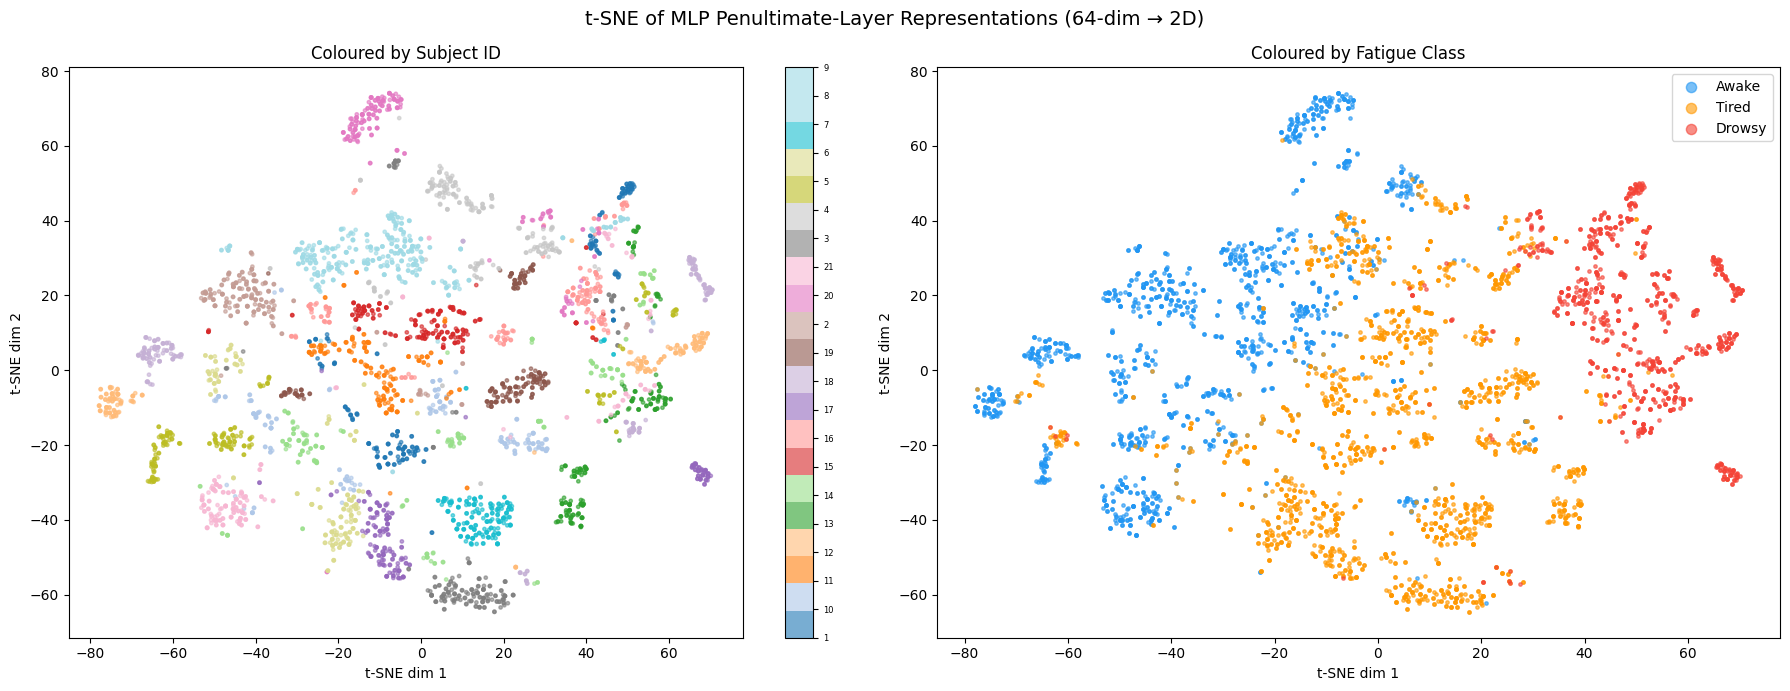

Saved: /kaggle/working/stage5A_tsne.png


In [37]:
# ── Block 5A.4 — t-SNE Visualization ─────────────────────────────────────────
#
# WHY THIS BLOCK EXISTS:
# t-SNE projects the 64-dimensional representations into 2D for visual
# inspection. Two plots are generated:
#
#   Plot 1 — coloured by SUBJECT ID:
#     Tight separated clusters → identity leakage is real.
#     Interleaved subjects     → representations are subject-agnostic.
#
#   Plot 2 — coloured by FATIGUE CLASS:
#     Tight class clusters     → model learned task-relevant structure.
#     Mixed classes            → model did not learn fatigue well.
#
# The combination diagnoses what the model actually encoded:
#   Subject clusters + mixed fatigue  → pure identity leakage
#   Mixed subjects + fatigue clusters → ideal cross-subject model
#   Both clustered                    → both signals present (most common)
#   Both mixed                        → model learned neither
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE

# ── Subsample for speed (t-SNE is O(N^2)) ─────────────────────────────────────
TSNE_MAX_PER_SUBJECT = 200
rng_tsne = np.random.default_rng(42)

tsne_indices = []
for subj in unique_subjects:
    subj_idx = np.where(all_subj_arr == subj)[0]
    if len(subj_idx) > TSNE_MAX_PER_SUBJECT:
        subj_idx = rng_tsne.choice(subj_idx, TSNE_MAX_PER_SUBJECT, replace=False)
    tsne_indices.append(subj_idx)

tsne_indices   = np.concatenate(tsne_indices)
X_tsne_input   = all_reprs_arr[tsne_indices]
y_tsne_subj    = all_subj_arr[tsne_indices]
y_tsne_fatigue = all_labels_arr[tsne_indices]

X_tsne_scaled = StandardScaler().fit_transform(X_tsne_input)

print(f"Running t-SNE on {len(tsne_indices)} windows "
      f"(≤{TSNE_MAX_PER_SUBJECT} per subject) ...")

tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    init='pca',
    random_state=42,
    n_jobs=-1,
)
X_2d = tsne.fit_transform(X_tsne_scaled)
print("t-SNE complete.")

# ── Subject colour map ────────────────────────────────────────────────────────
subj_to_int = {s: i for i, s in enumerate(unique_subjects)}
subj_ints   = np.array([subj_to_int[s] for s in y_tsne_subj])
subj_cmap   = cm.get_cmap('tab20', N_SUBJECTS)

# ── Fatigue colour map ────────────────────────────────────────────────────────
fatigue_colors = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}
fatigue_labels_map = {0: 'Awake', 1: 'Tired', 2: 'Drowsy'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('t-SNE of MLP Penultimate-Layer Representations (64-dim → 2D)',
             fontsize=14)

# Plot 1: coloured by subject ID
scatter1 = axes[0].scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=subj_ints,
    cmap=subj_cmap,
    vmin=0, vmax=N_SUBJECTS - 1,
    s=6, alpha=0.6,
)
axes[0].set_title('Coloured by Subject ID', fontsize=12)
axes[0].set_xlabel('t-SNE dim 1')
axes[0].set_ylabel('t-SNE dim 2')
cbar1 = plt.colorbar(scatter1, ax=axes[0], ticks=range(N_SUBJECTS))
cbar1.set_ticklabels(unique_subjects)
cbar1.ax.tick_params(labelsize=6)

# Plot 2: coloured by fatigue class
for cls in [0, 1, 2]:
    mask_cls = y_tsne_fatigue == cls
    axes[1].scatter(
        X_2d[mask_cls, 0], X_2d[mask_cls, 1],
        c=fatigue_colors[cls],
        label=fatigue_labels_map[cls],
        s=6, alpha=0.6,
    )
axes[1].set_title('Coloured by Fatigue Class', fontsize=12)
axes[1].set_xlabel('t-SNE dim 1')
axes[1].set_ylabel('t-SNE dim 2')
axes[1].legend(markerscale=3, loc='upper right')

plt.tight_layout()
save_path_tsne = '/kaggle/working/stage5A_tsne.png'
plt.savefig(save_path_tsne, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path_tsne}")


Subject           MMD score   LOSO acc
----------------------------------------
1                  0.381423     0.7232
10                 0.293967     0.5220
11                 0.366069     0.5006
12                 0.344823     0.4169
13                 0.399449     0.2814
14                 0.339665     0.4520
15                 0.323273     0.1944
16                 0.399382     0.7266
17                 0.407285     0.1028
18                 0.319586     0.4949
19                 0.382355     0.2621
2                  0.431288     0.2565
20                 0.649672     0.2215
21                 0.374156     0.4542
3                  0.391171     0.8531
4                  0.276732     0.2927
5                  0.368157     0.4514
6                  0.346156     0.6836
7                  0.392263     0.1288
8                  0.390727     0.3119
9                  0.341454     0.4056

MMD vs LOSO Accuracy Correlation:
  Spearman r = -0.2987  (p = 0.1884)
  Pearson  r = -0.2189   (p =

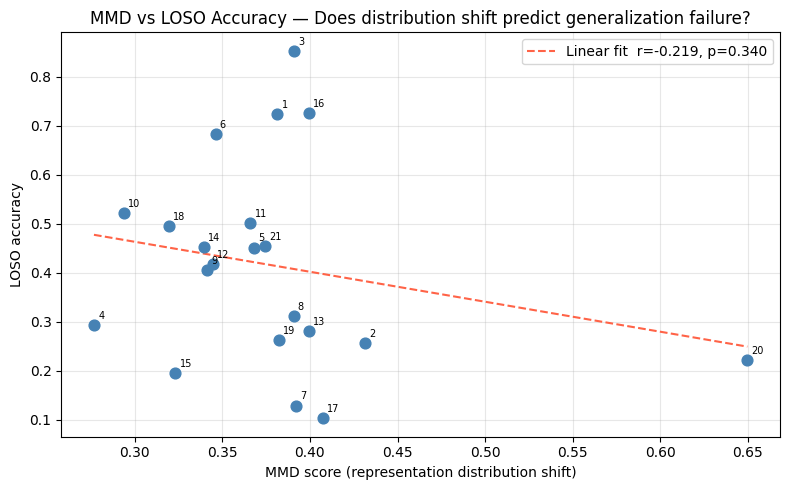

Saved: /kaggle/working/stage5A_mmd_vs_loso.png


In [38]:
# ── Block 5A.5 — MMD vs LOSO Accuracy Analysis ───────────────────────────────
#
# WHY THIS BLOCK EXISTS:
# Maximum Mean Discrepancy (MMD) measures the distance between two
# probability distributions in a reproducing kernel Hilbert space.
# Here we compute, for each test subject, the MMD between:
#   - the test subject's representation distribution
#   - the pooled training subjects' representation distribution
#
# If distribution shift is the primary cause of generalization failure,
# we expect a NEGATIVE Spearman correlation between MMD and LOSO accuracy:
# subjects with larger distribution shift should achieve lower LOSO accuracy.
#
# We use the unbiased RBF-kernel MMD^2 estimator with the median heuristic
# for bandwidth selection — standard, parameter-free, and well-motivated.
# ─────────────────────────────────────────────────────────────────────────────

def rbf_kernel(X: np.ndarray, Y: np.ndarray, bandwidth: float) -> np.ndarray:
    """Compute RBF kernel matrix K(X, Y) of shape (n, m)."""
    diff    = X[:, None, :] - Y[None, :, :]    # (n, m, d)
    sq_dist = (diff ** 2).sum(axis=-1)          # (n, m)
    return np.exp(-sq_dist / (2.0 * bandwidth ** 2))


def mmd_unbiased(X: np.ndarray, Y: np.ndarray,
                 bandwidth: float = None) -> float:
    """
    Unbiased MMD^2 estimate using RBF kernel.

    Parameters
    ----------
    X         : (n, d) training distribution samples
    Y         : (m, d) test subject samples
    bandwidth : RBF bandwidth. If None, uses median heuristic on X.

    Returns
    -------
    mmd (not mmd^2) — clipped at 0 for reporting.
    """
    if bandwidth is None:
        X_sub   = X[np.random.default_rng(42).choice(
                      len(X), min(500, len(X)), replace=False)]
        diffs   = X_sub[:, None, :] - X_sub[None, :, :]
        sq_d    = (diffs ** 2).sum(axis=-1)
        bw      = float(np.sqrt(np.median(sq_d[sq_d > 0])))
        bandwidth = max(bw, 1e-6)

    n, m = len(X), len(Y)

    Kxx = rbf_kernel(X, X, bandwidth)
    Kyy = rbf_kernel(Y, Y, bandwidth)
    Kxy = rbf_kernel(X, Y, bandwidth)

    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    mmd2 = (Kxx.sum() / (n * (n - 1))
            + Kyy.sum() / (m * (m - 1))
            - 2.0 * Kxy.mean())
    return float(np.sqrt(max(mmd2, 0.0)))


# ── Normalise representations (bandwidth is scale-sensitive) ──────────────────
scaler_mmd   = StandardScaler().fit(all_reprs_arr)
reprs_normed = scaler_mmd.transform(all_reprs_arr)

MMD_MAX_PER_SUBJECT = 300
MMD_MAX_TRAIN       = 2000
rng_mmd = np.random.default_rng(42)

mmd_results = []

print(f"{'Subject':<14} {'MMD score':>12} {'LOSO acc':>10}")
print('-' * 40)

for test_subj in unique_subjects:
    test_mask  = all_subj_arr == test_subj
    train_mask = ~test_mask

    Y_raw = reprs_normed[test_mask]
    X_raw = reprs_normed[train_mask]

    n_te = min(MMD_MAX_PER_SUBJECT, len(Y_raw))
    n_tr = min(MMD_MAX_TRAIN, len(X_raw))
    Y_s  = Y_raw[rng_mmd.choice(len(Y_raw), n_te, replace=False)]
    X_s  = X_raw[rng_mmd.choice(len(X_raw), n_tr, replace=False)]

    mmd_score = mmd_unbiased(X_s, Y_s)

    subj_loso_accs = [r['accuracy'] for r in all_results
                      if r['subject_id'] == test_subj]
    loso_acc = float(np.mean(subj_loso_accs)) if subj_loso_accs else np.nan

    print(f"{test_subj:<14} {mmd_score:>12.6f} {loso_acc:>10.4f}")

    mmd_results.append({
        'subject_id':    test_subj,
        'mmd_score':     mmd_score,
        'loso_accuracy': loso_acc,
    })

# ── Correlation ───────────────────────────────────────────────────────────────
mmd_arr  = np.array([r['mmd_score']     for r in mmd_results])
loso_arr = np.array([r['loso_accuracy'] for r in mmd_results])
valid    = ~np.isnan(loso_arr)

r_spearman, p_spearman = stats.spearmanr(mmd_arr[valid], loso_arr[valid])
r_pearson,  p_pearson  = stats.pearsonr(mmd_arr[valid],  loso_arr[valid])

print()
print('MMD vs LOSO Accuracy Correlation:')
print(f"  Spearman r = {r_spearman:.4f}  (p = {p_spearman:.4f})")
print(f"  Pearson  r = {r_pearson:.4f}   (p = {p_pearson:.4f})")

# ── Scatter plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(mmd_arr, loso_arr, color='steelblue', s=60, zorder=3)

for r in mmd_results:
    ax.annotate(r['subject_id'],
                (r['mmd_score'], r['loso_accuracy']),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

if valid.sum() > 2:
    m_fit, b_fit = np.polyfit(mmd_arr[valid], loso_arr[valid], 1)
    x_line = np.linspace(mmd_arr.min(), mmd_arr.max(), 100)
    ax.plot(x_line, m_fit * x_line + b_fit, color='tomato', linestyle='--',
            label=f'Linear fit  r={r_pearson:.3f}, p={p_pearson:.3f}')

ax.set_xlabel('MMD score (representation distribution shift)')
ax.set_ylabel('LOSO accuracy')
ax.set_title('MMD vs LOSO Accuracy — Does distribution shift predict generalization failure?')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_path_mmd = '/kaggle/working/stage5A_mmd_vs_loso.png'
plt.savefig(save_path_mmd, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path_mmd}")



In [42]:
# ── Block 5A.6 — Stage 5A Summary Table ──────────────────────────────────────
#
# Consolidates per-subject probe recall, LOSO accuracy, within-subject
# accuracy, MMD score, and generalization gap into a single dataframe.
#
# VARIABLES CONSUMED FROM EARLIER BLOCKS:
#   probe_mean_acc, probe_std_acc, probe_pval, probe_ratio, probe_tier
#     — from the revised Block 5A.3 (stratified window-level probe)
#   y_true_last, y_pred_last, unique_subjects, y_subj_encoded
#     — from the per-subject recall loop at the end of Block 5A.3
#   last_test_idx
#     — from the last split of Block 5A.3
#   mmd_results   — from Block 5A.5
#   all_results   — from Stage 1 LOSO evaluation
#   ws_results    — from Block 4.9 within-subject experiment
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from scipy import stats

# ── Step 1: Build per-subject probe recall from the last split ────────────────
# The revised Block 5A.3 reports a single mean probe accuracy across all
# subjects. Here we extract per-subject recall from the last split so that
# the summary table has one row per subject with comparable per-subject numbers.

per_subject_probe = {}
for cls_int, subj_name in enumerate(unique_subjects):
    mask = y_true_last == cls_int
    if mask.sum() == 0:
        per_subject_probe[subj_name] = np.nan
    else:
        per_subject_probe[subj_name] = accuracy_score(
            y_true_last[mask], y_pred_last[mask]
        )

# ── Step 2: Build per-subject LOSO accuracy lookup ────────────────────────────
# Subjects 4 and 5 have two sessions each; average across sessions.
loso_lookup = {}
for r in all_results:
    sid = r['subject_id']
    loso_lookup.setdefault(sid, []).append(r['accuracy'])
loso_lookup = {sid: float(np.mean(vals)) for sid, vals in loso_lookup.items()}

# ── Step 3: Build per-subject within-subject accuracy lookup ──────────────────
ws_lookup = {}
for r in ws_results:
    sid = r['subject_id']
    ws_lookup.setdefault(sid, []).append(r['within_subject_acc'])
ws_lookup = {sid: float(np.mean(vals)) for sid, vals in ws_lookup.items()}

# ── Step 4: Build per-subject MMD lookup ──────────────────────────────────────
mmd_lookup = {r['subject_id']: r['mmd_score'] for r in mmd_results}

# ── Step 5: Assemble summary dataframe ────────────────────────────────────────
summary_5a = pd.DataFrame([
    {
        'subject_id':         subj,
        'probe_recall':       per_subject_probe.get(subj, np.nan),
        'loso_accuracy':      loso_lookup.get(subj, np.nan),
        'within_subject_acc': ws_lookup.get(subj, np.nan),
        'mmd_score':          mmd_lookup.get(subj, np.nan),
    }
    for subj in unique_subjects
])

summary_5a['generalization_gap'] = (
    summary_5a['within_subject_acc'] - summary_5a['loso_accuracy']
)

summary_5a = summary_5a.sort_values('loso_accuracy').reset_index(drop=True)

# ── Step 6: Print the table ───────────────────────────────────────────────────
print('=' * 82)
print('Stage 5A — Per-Subject Summary')
print('=' * 82)
print(f"{'subject_id':<14} {'probe_recall':>13} {'loso_accuracy':>14} "
      f"{'within_subj':>12} {'gen_gap':>9} {'mmd_score':>10}")
print('-' * 82)

for _, row in summary_5a.iterrows():
    print(
        f"{row['subject_id']:<14}"
        f"{row['probe_recall']:>12.4f} "
        f"{row['loso_accuracy']:>14.4f} "
        f"{row['within_subject_acc']:>12.4f} "
        f"{row['generalization_gap']:>9.4f} "
        f"{row['mmd_score']:>10.6f}"
    )

# ── Step 7: Aggregate statistics ──────────────────────────────────────────────
chance_acc   = 1.0 / N_SUBJECTS
mean_loso    = summary_5a['loso_accuracy'].mean()
mean_ws      = summary_5a['within_subject_acc'].mean()
mean_gap     = summary_5a['generalization_gap'].mean()
mean_mmd     = summary_5a['mmd_score'].mean()
std_mmd      = summary_5a['mmd_score'].std()

# Correlations between MMD / probe recall and LOSO accuracy
valid = summary_5a[['probe_recall', 'loso_accuracy',
                     'mmd_score', 'generalization_gap']].dropna()

r_mmd_loso,   p_mmd_loso   = stats.spearmanr(valid['mmd_score'],    valid['loso_accuracy'])
r_probe_loso, p_probe_loso = stats.spearmanr(valid['probe_recall'],  valid['loso_accuracy'])
r_mmd_gap,    p_mmd_gap    = stats.spearmanr(valid['mmd_score'],     valid['generalization_gap'])
r_probe_gap,  p_probe_gap  = stats.spearmanr(valid['probe_recall'],  valid['generalization_gap'])

print()
print('─' * 64)
print(f"  Mean LOSO accuracy          : {mean_loso:.4f}")
print(f"  Mean within-subject acc     : {mean_ws:.4f}")
print(f"  Mean generalization gap     : {mean_gap:.4f}")
print()
print(f"  Probe accuracy (overall)    : {probe_mean_acc:.4f} ± {probe_std_acc:.4f}")
print(f"  Chance accuracy             : {chance_acc:.4f}  ({100*chance_acc:.2f}%)")
print(f"  Probe / chance ratio        : {probe_ratio:.2f}×")
print(f"  Probe t-test p-value        : {probe_pval:.4e}")
print(f"  Leakage tier                : {probe_tier}")
print()
print(f"  Mean MMD score              : {mean_mmd:.6f} ± {std_mmd:.6f}")
print()
print(f"  Spearman(MMD,   LOSO acc)   : r = {r_mmd_loso:+.4f}  p = {p_mmd_loso:.4f}")
print(f"  Spearman(probe, LOSO acc)   : r = {r_probe_loso:+.4f}  p = {p_probe_loso:.4f}")
print(f"  Spearman(MMD,   gen. gap)   : r = {r_mmd_gap:+.4f}  p = {p_mmd_gap:.4f}")
print(f"  Spearman(probe, gen. gap)   : r = {r_probe_gap:+.4f}  p = {p_probe_gap:.4f}")
print('─' * 64)

# ── Step 8: Final consolidated verdict ────────────────────────────────────────
print()
print('STAGE 5A CONSOLIDATED VERDICT:')
print()
print(f"  [LEAKAGE]  {probe_tier} subject identity leakage detected.")
print(f"             Probe = {probe_mean_acc:.4f}  ({probe_ratio:.1f}× chance,  "
      f"p = {probe_pval:.2e})")
print()

shift_predicts_loso = abs(r_mmd_loso) > 0.4 and p_mmd_loso < 0.05
shift_predicts_gap  = abs(r_mmd_gap)  > 0.4 and p_mmd_gap  < 0.05

if shift_predicts_loso or shift_predicts_gap:
    print(f"  [MMD]      Distribution shift predicts generalization difficulty.")
    print(f"             Spearman(MMD, LOSO) = {r_mmd_loso:+.3f}  (p={p_mmd_loso:.3f})")
    print(f"             Spearman(MMD, gap)  = {r_mmd_gap:+.3f}  (p={p_mmd_gap:.3f})")
    print(f"             Stage 5B (adversarial disentanglement) is well-motivated.")
else:
    print(f"  [MMD]      Distribution shift does NOT reliably predict LOSO accuracy.")
    print(f"             Spearman(MMD, LOSO) = {r_mmd_loso:+.3f}  (p={p_mmd_loso:.3f})")
    print(f"             Stage 5C (label boundary shift) may be the stronger explanation.")

# ── Step 9: Save outputs ───────────────────────────────────────────────────────
csv_path = '/kaggle/working/stage5A_summary.csv'
summary_5a.to_csv(csv_path, index=False)

print()
print(f"  Summary CSV   : {csv_path}")
print(f"  t-SNE figure  : /kaggle/working/stage5A_tsne.png")
print(f"  MMD figure    : /kaggle/working/stage5A_mmd_vs_loso.png")
print()
print('Stage 5A complete.')

Stage 5A — Per-Subject Summary
subject_id      probe_recall  loso_accuracy  within_subj   gen_gap  mmd_score
----------------------------------------------------------------------------------
17                  1.0000         0.1028       1.0000    0.8972   0.407285
7                   1.0000         0.1288       1.0000    0.8712   0.392263
15                  1.0000         0.1944       0.5819    0.3876   0.323273
20                  1.0000         0.2215       1.0000    0.7785   0.649672
2                   1.0000         0.2565       1.0000    0.7435   0.431288
19                  1.0000         0.2621       1.0000    0.7379   0.382355
13                  1.0000         0.2814       1.0000    0.7186   0.399449
4                   1.0000         0.2927       0.7429    0.4503   0.276732
8                   1.0000         0.3119       0.4181    0.1062   0.390727
9                   1.0000         0.4056       0.8418    0.4362   0.341454
12                  1.0000         0.4169       